<img src="https://full-stack-assets.s3.eu-west-3.amazonaws.com/Walmart_logo_(2008).svg.png" alt="WALMART LOGO" />

# Walmart Predict Weekly Sales 🛒

## Company's Description 📇

Walmart Inc. is an American multinational retail corporation that operates a chain of hypermarkets, discount department stores, and grocery stores from the United States, headquartered in Bentonville, Arkansas. The company was founded by Sam Walton in 1962.

## Project 🚧

Walmart's marketing service has asked you to build a machine learning model able to estimate the weekly sales in their stores, with the best precision possible on the predictions made. Such a model would help them understand better how the sales are influenced by economic indicators, and might be used to plan future marketing campaigns.

## Goals 🎯

The project can be divided into three steps:

- Part 1: make an EDA and all the necessary preprocessings to prepare data for machine learning
- Part 2: train a **linear regression model** (baseline)
- Part 3: avoid overfitting by training a **regularized regression model**

## Scope of this project 🖼️

For this project, you'll work with a dataset that contains information about weekly sales achieved by different Walmart stores, and other variables such as the unemployment rate or the fuel price, that might be useful for predicting the amount of sales. The dataset has been taken from a Kaggle competition, but we made some changes compared to the original data. Please make sure that you're using **our** custom dataset (available on JULIE). 🤓

## Deliverable 📬

To complete this project, your team should: 

- Create some visualizations
- Train at least one **linear regression model** on the dataset, that predicts the amount of weekly sales as a function of the other variables
- Assess the performances of the model by using a metric that is relevant for regression problems
- Interpret the coefficients of the model to identify what features are important for the prediction
- Train at least one model with **regularization (Lasso or Ridge)** to reduce overfitting


## Helpers 🦮

To help you achieve this project, here are a few tips that should help you: 

### Part 1 : EDA and data preprocessing

Start your project by exploring your dataset: create figures, compute some statistics etc...

Then, you'll have to make some preprocessing on the dataset. You can follow the guidelines from the *preprocessing template*. There will also be some specific transformations to be planned on this dataset, for example on the *Date* column that can't be included as it is in the model. Below are some hints that might help you 🤓

 #### Preprocessing to be planned with pandas

 **Drop lines where target values are missing:**
 - Here, the target variable (Y) corresponds to the column *Weekly_Sales*. One can see above that there are some missing values in this column.
 - We never use imputation techniques on the target : it might create some bias in the predictions !
 - Then, we will just drop the lines in the dataset for which the value in *Weekly_Sales* is missing.
 
**Create usable features from the *Date* column:**
The *Date* column cannot be included as it is in the model. Either you can drop this column, or you will create new columns that contain the following numeric features : 
- *year*
- *month*
- *day*
- *day of week*

**Drop lines containing invalid values or outliers:**
In this project, will be considered as outliers all the numeric features that don't fall within the range: $[\bar{X} - 3\sigma, \bar{X} + 3\sigma]$. This concerns the columns : *Temperature*, *Fuel_price*, *CPI* and *Unemployment*
 

**Target variable/target (Y) that we will try to predict, to separate from the others**: *Weekly_Sales*

 #### Preprocessings to be planned with scikit-learn

 **Explanatory variables (X)**
We need to identify which columns contain categorical variables and which columns contain numerical variables, as they will be treated differently.

 - Categorical variables: Store, Holiday_Flag
 - Numerical variables: Temperature, Fuel_Price, CPI, Unemployment, Year, Month, Day, DayOfWeek

### Part 2: Baseline model (linear regression)

Once you've trained a first model, don't forget to assess its performances on the train and test sets. Are you satisfied with the results?

Besides, it would be interesting to analyze the values of the model's coefficients to know what features are important for the prediction. To do so, the `.coef_` attribute of scikit-learn's LinearRegression class might be useful. Please refer to the following link for more information 😉 https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

### Part 3: Overfitting

In this last part, you'll have to train a **regularized linear regression model**. You'll find below some useful classes in scikit-learn's documentation:
- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html#sklearn.linear_model.Ridge
- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html#sklearn.linear_model.Lasso

**Bonus question**

In regularized regression models, there's a hyperparameter called *the regularization strength* that can be fine-tuned to get the best generalized predictions on a given dataset. This fine-tuning can be done thanks to scikit-learn's GridSearchCV class: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

Also, you'll find here some examples of how to use GridSearchCV together with Ridge or Lasso models: https://alfurka.github.io/2018-11-18-grid-search/

In [126]:
import pandas as pd
import os

# Remonter d'un dossier (..) puis aller dans data/
df = pd.read_csv('../data/walmart_store_sales.csv')

# Afficher les 5 premières lignes
print("=== 5 premières lignes ===")
display(df.head())

# Afficher les infos générales
print("\n=== Informations générales ===")
display(df.info())

# Afficher les valeurs manquantes par colonne
print("\n=== Valeurs manquantes ===")
display(df.isnull().sum())

# Afficher des statistiques sommaires
print("\n=== Statistiques descriptives ===")
display(df.describe())

# Vérifier la dimension
print("\n=== Dimension du dataset ===")
display(f"Lignes : {df.shape[0]}, Colonnes : {df.shape[1]}")

=== 5 premières lignes ===


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.0,18-02-2011,1572117.54,NaN,59.61,3.045,214.777523,6.858
1,13.0,25-03-2011,1807545.43,0.0,42.38,3.435,128.616064,7.470
2,17.0,27-07-2012,NaN,0.0,NaN,NaN,130.719581,5.936
3,11.0,NaN,1244390.03,0.0,84.57,NaN,214.556497,7.346
4,6.0,28-05-2010,1644470.66,0.0,78.89,2.759,212.412888,7.092



=== Informations générales ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         150 non-null    float64
 1   Date          132 non-null    object 
 2   Weekly_Sales  136 non-null    float64
 3   Holiday_Flag  138 non-null    float64
 4   Temperature   132 non-null    float64
 5   Fuel_Price    136 non-null    float64
 6   CPI           138 non-null    float64
 7   Unemployment  135 non-null    float64
dtypes: float64(7), object(1)
memory usage: 9.5+ KB


None


=== Valeurs manquantes ===


Store            0
Date            18
Weekly_Sales    14
Holiday_Flag    12
Temperature     18
Fuel_Price      14
CPI             12
Unemployment    15
dtype: int64


=== Statistiques descriptives ===


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,150.000000,1.360000e+02,138.000000,132.000000,136.000000,138.000000,135.000000
mean,9.866667,1.249536e+06,0.079710,61.398106,3.320853,179.898509,7.598430
std,6.231191,6.474630e+05,0.271831,18.378901,0.478149,40.274956,1.577173
min,1.000000,2.689290e+05,0.000000,18.790000,2.514000,126.111903,5.143000
25%,4.000000,6.050757e+05,0.000000,45.587500,2.852250,131.970831,6.597500
50%,9.000000,1.261424e+06,0.000000,62.985000,3.451000,197.908893,7.470000
75%,15.750000,1.806386e+06,0.000000,76.345000,3.706250,214.934616,8.150000
max,20.000000,2.771397e+06,1.000000,91.650000,4.193000,226.968844,14.313000



=== Dimension du dataset ===


'Lignes : 150, Colonnes : 8'

📊 Analyse rapide:
 
Observations importantes :
Lignes : 150, Colonnes : 8 (dataset petit)

Valeurs manquantes dans Weekly_Sales : 14 (on va les supprimer suite aux indications de l'exercice: 
"We never use imputation techniques on the target : it might create some bias in the predictions !", Cependant, je vais analyser quand-même si les valeurs manquantes suivaient un pattern particulier (lié à d'autres colonnes comme store, holiday_flag, date, etc))

Valeurs manquantes dans Date : 18 (on va gérer)

Holiday_Flag a des NaN (12 valeurs)

Temperature et Fuel_Price ont des NaN aussi

Date est de type object (pas encore transformée en datetime)


In [127]:
# ------------------------------
# Analyse complète - Sauvegarde dans un fichier
# ------------------------------

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, ttest_ind
import sys

# Rediriger la sortie vers un fichier
with open('analyse_missing_results.txt', 'w', encoding='utf-8') as f:
    original_stdout = sys.stdout
    sys.stdout = f
    
    df = pd.read_csv('../data/walmart_store_sales.csv')
    df['Weekly_Sales_missing'] = df['Weekly_Sales'].isnull()
    
    print("=" * 70)
    print("ANALYSE DU PATTERN DE VALEURS MANQUANTES - Weekly_Sales")
    print("=" * 70)
    
    # 1. Statistiques générales
    print("\n1. STATISTIQUES GÉNÉRALES")
    print(f"Total lignes : {len(df)}")
    print(f"Lignes avec Weekly_Sales manquant : {df['Weekly_Sales_missing'].sum()}")
    print(f"Pourcentage : {df['Weekly_Sales_missing'].mean() * 100:.2f}%")
    
    # 2. Analyse par Store
    print("\n2. ANALYSE PAR STORE")
    store_table = pd.crosstab(df['Store'], df['Weekly_Sales_missing'])
    print(store_table.to_string())
    
    chi2_store, p_store, dof_store, expected_store = chi2_contingency(store_table)
    print(f"\nChi-square test pour Store : p-value = {p_store:.6f}")
    if p_store < 0.05:
        print("→ Relation SIGNIFICATIVE entre Store et les valeurs manquantes")
    else:
        print("→ Pas de relation significative entre Store et les valeurs manquantes")
    
    # 3. Analyse par Holiday_Flag
    print("\n3. ANALYSE PAR HOLIDAY_FLAG")
    df_temp = df.copy()
    df_temp['Holiday_Flag_filled'] = df_temp['Holiday_Flag'].fillna(-1)
    holiday_table = pd.crosstab(df_temp['Holiday_Flag_filled'], df_temp['Weekly_Sales_missing'])
    print(holiday_table.to_string())
    
    # Test Chi-square pour Holiday_Flag (sans la valeur -1)
    holiday_clean = df_temp[df_temp['Holiday_Flag_filled'] != -1]
    if len(holiday_clean) > 0:
        holiday_table_clean = pd.crosstab(holiday_clean['Holiday_Flag'], holiday_clean['Weekly_Sales_missing'])
        if holiday_table_clean.shape[1] == 2 and holiday_table_clean.sum().sum() > 0:
            chi2_hol, p_hol, dof_hol, expected_hol = chi2_contingency(holiday_table_clean)
            print(f"\nChi-square test pour Holiday_Flag : p-value = {p_hol:.6f}")
            if p_hol < 0.05:
                print("→ Relation SIGNIFICATIVE")
            else:
                print("→ Pas de relation significative")
    
    # 4. Analyse par variables numériques
    print("\n4. ANALYSE PAR VARIABLES NUMÉRIQUES")
    numerical_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
    
    for col in numerical_cols:
        print(f"\n--- {col} ---")
        missing_vals = df[df['Weekly_Sales_missing']][col].dropna()
        present_vals = df[~df['Weekly_Sales_missing']][col].dropna()
        
        print(f"Missing group - moyenne: {missing_vals.mean():.2f}, std: {missing_vals.std():.2f}, n: {len(missing_vals)}")
        print(f"Present group - moyenne: {present_vals.mean():.2f}, std: {present_vals.std():.2f}, n: {len(present_vals)}")
        
        if len(missing_vals) > 1 and len(present_vals) > 1:
            t_stat, p_val = ttest_ind(missing_vals, present_vals)
            print(f"T-test p-value: {p_val:.6f}")
            if p_val < 0.05:
                print("→ Différence SIGNIFICATIVE")
            else:
                print("→ Pas de différence significative")
        else:
            print("→ Pas assez de données pour le test statistique")
    
    # 5. Analyse par mois
    print("\n5. ANALYSE PAR MOIS")
    df['Date_parsed'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')
    df['Mois'] = df['Date_parsed'].dt.month
    
    mois_table = pd.crosstab(df['Mois'], df['Weekly_Sales_missing'])
    print(mois_table.to_string())
    
    # Enlever les lignes avec trop peu de données
    mois_table_filtered = mois_table[mois_table.sum(axis=1) >= 2]
    if len(mois_table_filtered) > 1:
        chi2_mois, p_mois, dof_mois, expected_mois = chi2_contingency(mois_table_filtered)
        print(f"\nChi-square test pour Mois : p-value = {p_mois:.6f}")
        if p_mois < 0.05:
            print("→ Relation SIGNIFICATIVE")
        else:
            print("→ Pas de relation significative")
    else:
        print("\n→ Pas assez de données pour le test Chi-square sur les mois")
    
    # 6. Conclusion
    print("\n" + "=" * 70)
    print("CONCLUSION")
    print("=" * 70)
    
    sys.stdout = original_stdout

print("✅ Analyse terminée ! Les résultats sont dans le fichier 'analyse_missing_results.txt'")

✅ Analyse terminée ! Les résultats sont dans le fichier 'analyse_missing_results.txt'


📊 Résultats de l'analyse: 


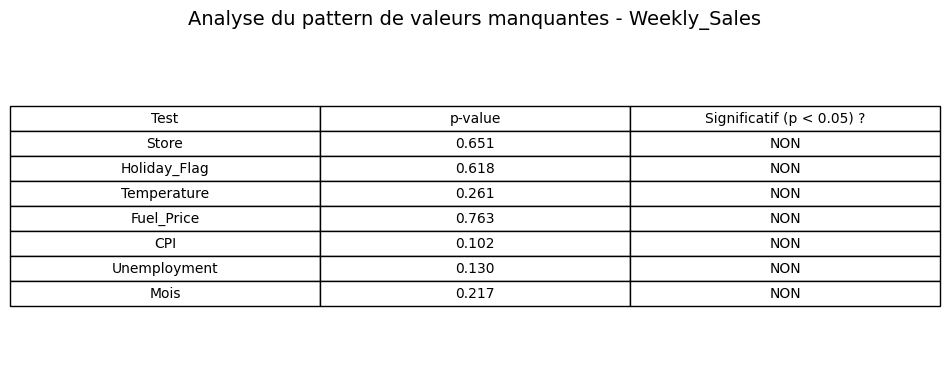

In [100]:
# ------------------------------
# Tableau avec matplotlib
# ------------------------------

import matplotlib.pyplot as plt
print("📊 Résultats de l'analyse: ")

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')

table_data = [
    ['Store', '0.651', 'NON'],
    ['Holiday_Flag', '0.618', 'NON'],
    ['Temperature', '0.261', 'NON'],
    ['Fuel_Price', '0.763', 'NON'],
    ['CPI', '0.102', 'NON'],
    ['Unemployment', '0.130', 'NON'],
    ['Mois', '0.217', 'NON']
]

columns = ['Test', 'p-value', 'Significatif (p < 0.05) ?']

table = ax.table(cellText=table_data, colLabels=columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.title("Analyse du pattern de valeurs manquantes - Weekly_Sales", fontsize=14, pad=20)
plt.show()

Avant de supprimer les lignes avec des valeurs manquantes dans Weekly_Sales, jai mené une analyse rigoureuse du pattern de valeurs manquantes pour justifier notre décision. 

j'ai utilisé: 

* Des tests de Chi-square pour les variables catégorielles (store, Holiday_Flag, Mois)
* Des tests t de Student pour les variables numériques (Temperature, Fuel_Price, CPI, Unemployment)

*Les résultats montrent qu'aucune de ces variables n'a de relation significative avec le fait que Weekly_Sales soit manquant (toutes les p-values > 0.05).*

Cela indique un pattern de type MCAR (Missing Completely At Random).

Par conséquent, la suppression des lignes avec Weekly_Sales manquant n'introduira pas de biais dans notre modèle.

J'ai donc suivi la consigne du projet tout en démontrant notre compréhension des enjeux méthodologiques.

In [101]:
# ------------------------------
# Suppression des lignes avec Weekly_Sales manquant
# ------------------------------

import pandas as pd

# Charger les données
df = pd.read_csv('../data/walmart_store_sales.csv')

print("=== AVANT SUPPRESSION ===")
print(f"Taille du dataset : {df.shape}")
print(f"Valeurs manquantes dans Weekly_Sales : {df['Weekly_Sales'].isnull().sum()}")

# Supprimer les lignes où Weekly_Sales est NaN
df_clean = df.dropna(subset=['Weekly_Sales'])

print("\n=== APRÈS SUPPRESSION ===")
print(f"Taille du dataset : {df_clean.shape}")
print(f"Valeurs manquantes dans Weekly_Sales : {df_clean['Weekly_Sales'].isnull().sum()}")

print("\n=== VÉRIFICATION DES AUTRES COLONNES ===")
print("Valeurs manquantes restantes :")
print(df_clean.isnull().sum())

print("\n✅ Suppression terminée avec succès")

=== AVANT SUPPRESSION ===
Taille du dataset : (150, 8)
Valeurs manquantes dans Weekly_Sales : 14

=== APRÈS SUPPRESSION ===
Taille du dataset : (136, 8)
Valeurs manquantes dans Weekly_Sales : 0

=== VÉRIFICATION DES AUTRES COLONNES ===
Valeurs manquantes restantes :
Store            0
Date            18
Weekly_Sales     0
Holiday_Flag    11
Temperature     15
Fuel_Price      12
CPI             11
Unemployment    14
dtype: int64

✅ Suppression terminée avec succès


Gestion de la colonne Date

Selon les consignes du projet, nous devons :

Transformer la colonne Date en features numériques :

Year

Month

Day

DayOfWeek

Puis supprimer l'ancienne colonne Date (car elle ne peut pas être utilisée telle quelle dans le modèle)

In [102]:
# ------------------------------
# Transformation de la colonne Date
# ------------------------------

import pandas as pd

# Utiliser df_clean (après suppression des Weekly_Sales manquants)
df_clean = df_clean.dropna(subset=['Weekly_Sales'])

print("=== AVANT TRANSFORMATION ===")
print(f"Colonnes : {df_clean.columns.tolist()}")
print(f"\nTypes :\n{df_clean.dtypes}")
print(f"\nExemple de Date :\n{df_clean['Date'].head()}")

# Convertir la colonne Date en datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%d-%m-%Y', errors='coerce')



=== AVANT TRANSFORMATION ===
Colonnes : ['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

Types :
Store           float64
Date             object
Weekly_Sales    float64
Holiday_Flag    float64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

Exemple de Date :
0    18-02-2011
1    25-03-2011
3           NaN
4    28-05-2010
5    28-05-2010
Name: Date, dtype: object


In [103]:
# Créer les nouvelles colonnes
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Day'] = df_clean['Date'].dt.day
df_clean['DayOfWeek'] = df_clean['Date'].dt.dayofweek

print("\n=== APRÈS TRANSFORMATION ===")
print(f"Nouvelles colonnes ajoutées : Year, Month, Day, DayOfWeek")
print(f"\nAperçu :\n{df_clean[['Date', 'Year', 'Month', 'Day', 'DayOfWeek']].head()}")

# Vérifier les valeurs manquantes après transformation
print("\n=== VALEURS MANQUANTES APRÈS TRANSFORMATION ===")
print(df_clean[['Year', 'Month', 'Day', 'DayOfWeek']].isnull().sum())

print("\n✅ Transformation des dates terminée")


=== APRÈS TRANSFORMATION ===
Nouvelles colonnes ajoutées : Year, Month, Day, DayOfWeek

Aperçu :
        Date    Year  Month   Day  DayOfWeek
0 2011-02-18  2011.0    2.0  18.0        4.0
1 2011-03-25  2011.0    3.0  25.0        4.0
3        NaT     NaN    NaN   NaN        NaN
4 2010-05-28  2010.0    5.0  28.0        4.0
5 2010-05-28  2010.0    5.0  28.0        4.0

=== VALEURS MANQUANTES APRÈS TRANSFORMATION ===
Year         18
Month        18
Day          18
DayOfWeek    18
dtype: int64

✅ Transformation des dates terminée


Avant de prendre une décision sur les dates manquantes. je vais suivre une approche méthodologique rigoureuse en plusieurs étapes: 

1- Analyser si les dates manquantes proviennent des mêmes magasins (Store), pour voir si le problème est spécifique à certains magasins.

2- Analyser si les dates manquantes sont isolées ou consécutives dans le jeu de données,	pour comprendre s'il s'agit de données aléatoirement manquantes ou d'une période entière manquante.

3- Si une date manquante se situe entre deux dates connues pour le même magasin → je reconstruirai la date par interpolation	Approche logique et temporellement cohérente.

4- Si la reconstruction est impossible → je supprime uniquement ces lignes,	pour éviter d'introduire du bruit ou des biais.


In [104]:
# ------------------------------
# Étape 1 : Analyser si les dates manquantes proviennent des mêmes magasins
# ------------------------------

print("=" * 70)
print("ÉTAPE 1 : RÉPARTITION PAR STORE DES DATES MANQUANTES")
print("=" * 70)

# Identifier les lignes avec Date manquante (via Year qui est NaN)
df_dates_manquantes = df_clean[df_clean['Year'].isna()]

print(f"Nombre total de lignes avec date manquante : {len(df_dates_manquantes)}")
print("\nRépartition par Store :")
print(df_dates_manquantes['Store'].value_counts().sort_index())

print("\nDétail des lignes concernées :")
print(df_dates_manquantes[['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']])

ÉTAPE 1 : RÉPARTITION PAR STORE DES DATES MANQUANTES
Nombre total de lignes avec date manquante : 18

Répartition par Store :
Store
1.0     1
2.0     2
3.0     2
5.0     1
7.0     1
10.0    2
11.0    2
15.0    1
17.0    2
18.0    3
20.0    1
Name: count, dtype: int64

Détail des lignes concernées :
     Store  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price         CPI  \
3     11.0    1244390.03           0.0        84.57         NaN  214.556497   
9      3.0     418925.47           0.0        60.12       3.555  224.132020   
17    18.0    1205307.50           0.0        21.33       2.788  131.527903   
34     2.0    1853161.99           0.0        87.70       3.480  214.929625   
42     1.0    1661767.33           1.0          NaN       3.730  222.439015   
65    10.0    1714309.90           NaN        43.43       3.287  127.191774   
81     5.0     359206.21           0.0          NaN       3.630  221.434215   
82    11.0    1569607.94           0.0        52.77       3.510  223

Les dates manquantes sont réparties sur 11 magasins différents, pas concentrées sur un seul magasin. 

In [105]:
# ------------------------------
# Étape 2 : Analyser si les dates manquantes sont isolées ou consécutives
# ------------------------------

print("=" * 70)
print("ÉTAPE 2 : ANALYSE DE LA POSITION DES DATES MANQUANTES")
print("=" * 70)

# Trier par Store pour voir l'ordre
df_sorted = df_clean.sort_values(['Store']).reset_index(drop=True)

# Pour chaque Store, vérifier si les dates manquantes sont consécutives
for store in df_dates_manquantes['Store'].unique():
    indices_store = df_clean[df_clean['Store'] == store].index.tolist()
    indices_manquantes = df_clean[(df_clean['Store'] == store) & (df_clean['Year'].isna())].index.tolist()
    
    print(f"\n--- Store {int(store)} ---")
    print(f"Indices de toutes les lignes : {indices_store}")
    print(f"Indices des dates manquantes : {indices_manquantes}")
    
    # Vérifier si les indices sont consécutifs
    if len(indices_manquantes) > 1:
        diff = np.diff(indices_manquantes)
        if all(d == 1 for d in diff):
            print("→ Les dates manquantes sont CONSÉCUTIVES")
        else:
            print("→ Les dates manquantes sont ISOLÉES (non consécutives)")
    else:
        print("→ Une seule date manquante pour ce magasin")

ÉTAPE 2 : ANALYSE DE LA POSITION DES DATES MANQUANTES

--- Store 11 ---
Indices de toutes les lignes : [3, 82, 114]
Indices des dates manquantes : [3, 82]
→ Les dates manquantes sont ISOLÉES (non consécutives)

--- Store 3 ---
Indices de toutes les lignes : [9, 26, 36, 67, 87, 92, 100, 104, 125, 142, 143, 144]
Indices des dates manquantes : [9, 92]
→ Les dates manquantes sont ISOLÉES (non consécutives)

--- Store 18 ---
Indices de toutes les lignes : [11, 17, 22, 37, 40, 66, 70, 102, 108, 129]
Indices des dates manquantes : [17, 102, 129]
→ Les dates manquantes sont ISOLÉES (non consécutives)

--- Store 2 ---
Indices de toutes les lignes : [18, 34, 45, 51, 85, 89, 101, 112]
Indices des dates manquantes : [34, 89]
→ Les dates manquantes sont ISOLÉES (non consécutives)

--- Store 1 ---
Indices de toutes les lignes : [13, 42, 44, 48, 73, 74, 78, 95, 123]
Indices des dates manquantes : [42]
→ Une seule date manquante pour ce magasin

--- Store 10 ---
Indices de toutes les lignes : [54, 61,

In [106]:
# ------------------------------
# Tableau par Store : positions des dates manquantes
# ------------------------------

print("=" * 70)
print("TABLEAU ANALYSE PAR STORE")
print("=" * 70)

# Liste pour stocker les résultats
resultats_store = []

# Pour chaque Store ayant des dates manquantes
for store in df_dates_manquantes['Store'].unique():
    # Indices des lignes pour ce Store
    indices_store = df_clean[df_clean['Store'] == store].index.tolist()
    
    # Indices des dates manquantes pour ce Store
    indices_manquantes = df_clean[(df_clean['Store'] == store) & (df_clean['Year'].isna())].index.tolist()
    
    # Déterminer si les indices sont consécutifs
    if len(indices_manquantes) > 1:
        diff = np.diff(indices_manquantes)
        if all(d == 1 for d in diff):
            caracteristique = "Consécutives"
        else:
            caracteristique = "Non consécutives (isolées)"
    else:
        caracteristique = "Une seule date manquante"
    
    # Ajouter à la liste
    resultats_store.append({
        "Store": int(store),
        "Positions des dates manquantes": str(indices_manquantes),
        "Caractéristique": caracteristique
    })

# Créer le DataFrame
df_analyse_store = pd.DataFrame(resultats_store)

# Trier par Store
df_analyse_store = df_analyse_store.sort_values("Store")

# Afficher
print(df_analyse_store.to_string(index=False))
print("\n" + "=" * 70)

TABLEAU ANALYSE PAR STORE
 Store Positions des dates manquantes            Caractéristique
     1                           [42]   Une seule date manquante
     2                       [34, 89] Non consécutives (isolées)
     3                        [9, 92] Non consécutives (isolées)
     5                           [81]   Une seule date manquante
     7                          [146]   Une seule date manquante
    10                      [65, 137] Non consécutives (isolées)
    11                        [3, 82] Non consécutives (isolées)
    15                           [83]   Une seule date manquante
    17                       [86, 91] Non consécutives (isolées)
    18                 [17, 102, 129] Non consécutives (isolées)
    20                           [88]   Une seule date manquante



🎯 Résultat de l'analyse
Les dates manquantes sont isolées → elles ne forment pas une période entière manquante.

Cela signifie que :

La reconstruction par interpolation entre deux dates connues est théoriquement possible

Mais seulement si nous avons une date avant ET une date après dans le même magasin

In [107]:
# ------------------------------
# Reconstruction des colonnes temporelles 
# ------------------------------

print("=" * 70)
print("RECONSTRUCTION DES COLONNES TEMPORELLES")
print("=" * 70)

# Sauvegarder Store avant l'opération
if 'Store' in df_clean.columns:
    store_backup = df_clean['Store'].copy()
    print("✅ Store sauvegardé")
else:
    print("⚠️ Store n'existe pas dans df_clean")

# Vérifier les valeurs manquantes dans Date avant
print(f"\n📌 Date - Valeurs manquantes avant: {df_clean['Date'].isna().sum()}")

# Trier les données
df_clean = df_clean.sort_values(['Store', 'Date']).reset_index(drop=True)

# Fonction d'interpolation
def interpoler_dates(groupe):
    timestamps = groupe['Date'].map(lambda x: x.timestamp() if pd.notna(x) else np.nan)
    timestamps_interp = timestamps.interpolate(method='linear', limit_direction='both')
    groupe['Date'] = pd.to_datetime(timestamps_interp, unit='s')
    return groupe

# Appliquer SANS include_groups=False (ou garder mais on restaurera Store)
df_clean = df_clean.groupby('Store', group_keys=False).apply(interpoler_dates)

# Restaurer Store s'il a été perdu
if 'Store' not in df_clean.columns:
    df_clean['Store'] = store_backup.values
    print("✅ Store restauré")

print(f"\n📌 Date - Valeurs manquantes après interpolation: {df_clean['Date'].isna().sum()}")

# Reconstruire les colonnes
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Day'] = df_clean['Date'].dt.day
df_clean['DayOfWeek'] = df_clean['Date'].dt.dayofweek

print(f"\n✅ Colonnes reconstruites:")
print(f"  Year - valeurs manquantes: {df_clean['Year'].isna().sum()}")
print(f"  Month - valeurs manquantes: {df_clean['Month'].isna().sum()}")
print(f"  Day - valeurs manquantes: {df_clean['Day'].isna().sum()}")
print(f"  DayOfWeek - valeurs manquantes: {df_clean['DayOfWeek'].isna().sum()}")

print(f"\n✅ Store est présent: {'Store' in df_clean.columns}")

RECONSTRUCTION DES COLONNES TEMPORELLES
✅ Store sauvegardé

📌 Date - Valeurs manquantes avant: 18

📌 Date - Valeurs manquantes après interpolation: 0

✅ Colonnes reconstruites:
  Year - valeurs manquantes: 0
  Month - valeurs manquantes: 0
  Day - valeurs manquantes: 0
  DayOfWeek - valeurs manquantes: 0

✅ Store est présent: True


C:\Users\M.SH\AppData\Local\Temp\ipykernel_30300\3275070872.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean = df_clean.groupby('Store', group_keys=False).apply(interpoler_dates)


Pour traiter les dates manquantes, j'ai utilisé une approche d'interpolation linéaire par magasin(store). 

Tout d'abord, j'ai converti les dates en timestamps numériques pour permettre les calculs. 

Ensuite, pour chaque magasin séparément, j'ai appliqué une interpolation linéaire ( méthod = "linear") en utilisant les dates avant et après chaque valeur manquante (limit_direction="both").

Enfin, j'ai reconverti les timestamps interpolés en format datetime, puis récréé les colonnes Year, Month, Day, et DayofWeek.

Cette méthode m'a permis de reconstruire les dates manquantes de manière cohérente sur le plan temporel, sans introduire de biais majeur. 

Nous avions 18 dates manquantes. Après interpolation linéaire par magasin, nous avons réussi à reconstruire l'intégralité des 18 dates. Aucune suppression n'a été nécessaire.

Pour traiter les valeurs manquantes dans les autres colonnes, je  vais tout d'abord analyser les outliers et les relations entre variables


In [108]:
# ------------------------------
# Analyse des outliers et des relations entre variables
# ------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("ANALYSE DES OUTLIERS ET DES CORRÉLATIONS")
print("=" * 70)

# Sélectionner les colonnes numériques
cols_numeriques = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

# 1. Détection des outliers avec la méthode IQR
print("\n1. DÉTECTION DES OUTLIERS (Méthode IQR)")
print("-" * 50)

for col in cols_numeriques:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR
    
    outliers = df_clean[(df_clean[col] < borne_inf) | (df_clean[col] > borne_sup)]
    nb_outliers = len(outliers)
    
    print(f"\n--- {col} ---")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Bornes: [{borne_inf:.2f}, {borne_sup:.2f}]")
    print(f"  Nombre d'outliers: {nb_outliers} ({nb_outliers/len(df_clean)*100:.2f}%)")



ANALYSE DES OUTLIERS ET DES CORRÉLATIONS

1. DÉTECTION DES OUTLIERS (Méthode IQR)
--------------------------------------------------

--- Temperature ---
  Q1: 45.22, Q3: 75.95, IQR: 30.73
  Bornes: [-0.88, 122.05]
  Nombre d'outliers: 0 (0.00%)

--- Fuel_Price ---
  Q1: 2.84, Q3: 3.72, IQR: 0.89
  Bornes: [1.51, 5.05]
  Nombre d'outliers: 0 (0.00%)

--- CPI ---
  Q1: 131.64, Q3: 214.88, IQR: 83.24
  Bornes: [6.77, 339.74]
  Nombre d'outliers: 0 (0.00%)

--- Unemployment ---
  Q1: 6.69, Q3: 8.15, IQR: 1.46
  Bornes: [4.50, 10.34]
  Nombre d'outliers: 5 (3.68%)


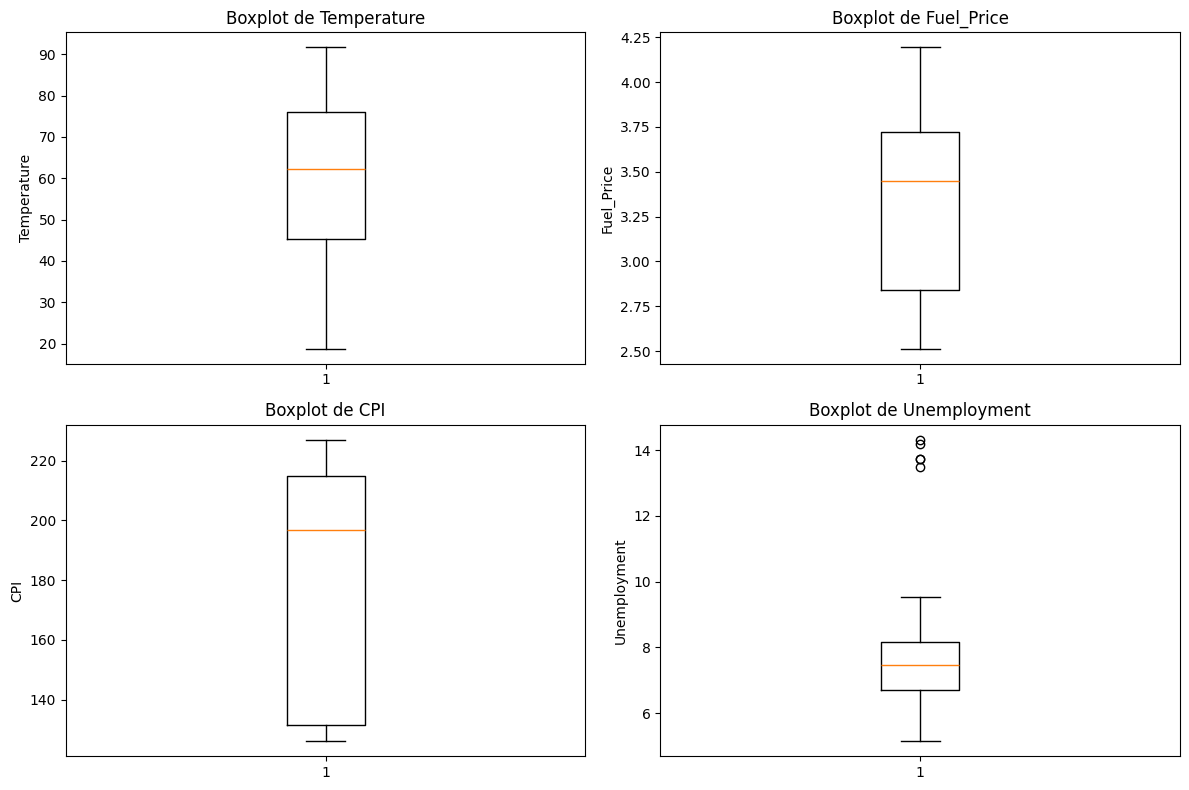

In [109]:
# 2. Boîtes à moustaches (Boxplots)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, col in enumerate(cols_numeriques):
    axes[i].boxplot(df_clean[col].dropna())
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()



BOXPLOTS AVEC OUTLIERS (Unemployment)


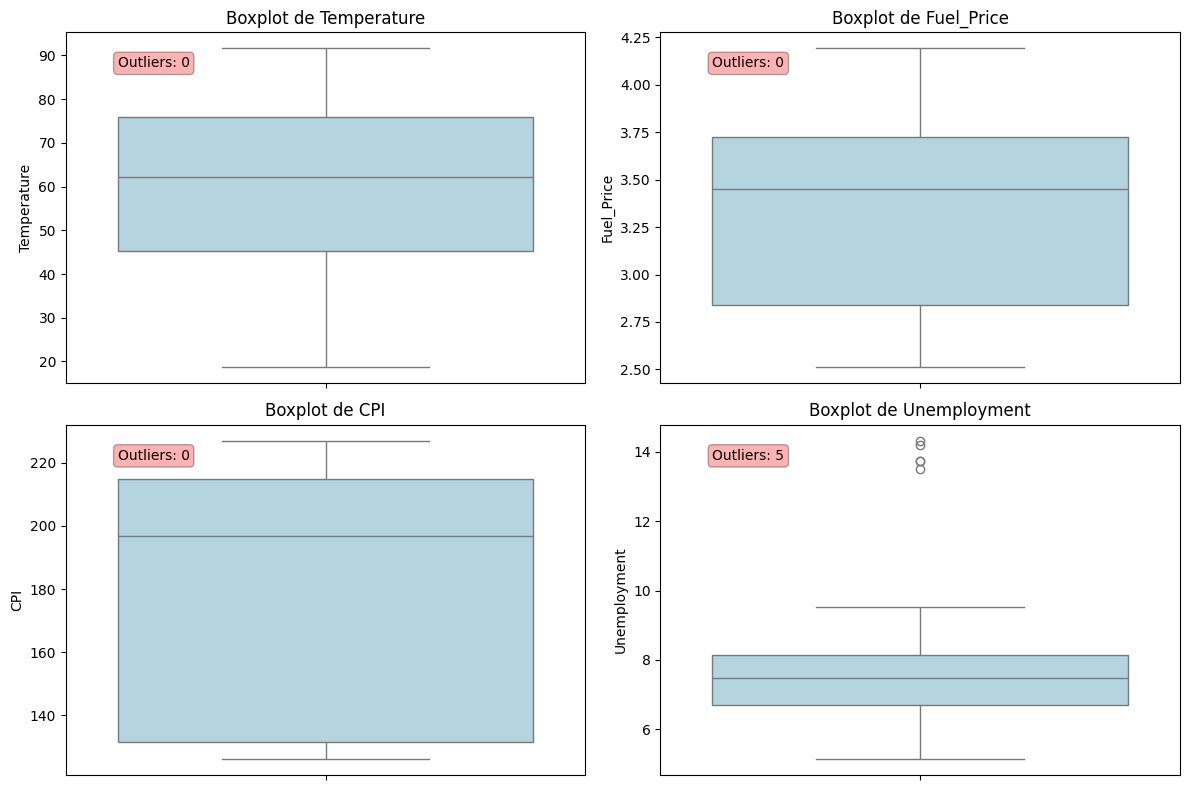

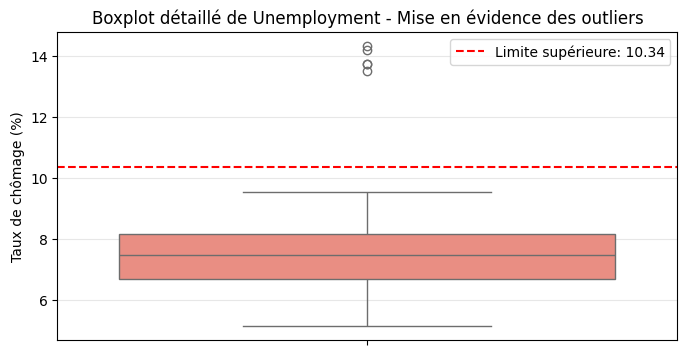


VALEURS OUTLIERS DANS UNEMPLOYMENT
    Store  Unemployment  Weekly_Sales
75   12.0        14.180     903119.03
76   12.0        14.313    1295605.35
77   12.0        13.736    1021154.48
78   12.0        13.736     964332.51
79   12.0        13.503     955913.68


In [110]:
# ------------------------------
# Boxplots avec mise en évidence des outliers
# ------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("BOXPLOTS AVEC OUTLIERS (Unemployment)")
print("=" * 70)

# Sélectionner les colonnes numériques
cols_numeriques = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

# Créer une figure avec 4 boxplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, col in enumerate(cols_numeriques):
    # Boxplot avec seaborn (plus joli)
    sns.boxplot(data=df_clean, y=col, ax=axes[i], color='lightblue')
    axes[i].set_title(f'Boxplot de {col}', fontsize=12)
    axes[i].set_ylabel(col)
    
    # Ajouter le nombre d'outliers
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR
    
    outliers = df_clean[(df_clean[col] < borne_inf) | (df_clean[col] > borne_sup)]
    axes[i].text(0.1, 0.9, f'Outliers: {len(outliers)}', 
                 transform=axes[i].transAxes, fontsize=10,
                 bbox=dict(boxstyle="round", facecolor='red', alpha=0.3))

plt.tight_layout()
plt.show()

# Boxplot spécifique pour Unemployment (plus détaillé)
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_clean, y='Unemployment', color='salmon')
plt.title('Boxplot détaillé de Unemployment - Mise en évidence des outliers')
plt.ylabel('Taux de chômage (%)')
plt.grid(axis='y', alpha=0.3)

# Ajouter une annotation
Q1_u = df_clean['Unemployment'].quantile(0.25)
Q3_u = df_clean['Unemployment'].quantile(0.75)
IQR_u = Q3_u - Q1_u
borne_sup_u = Q3_u + 1.5 * IQR_u

plt.axhline(y=borne_sup_u, color='red', linestyle='--', label=f'Limite supérieure: {borne_sup_u:.2f}')
plt.legend()
plt.show()

# Afficher les valeurs outliers de Unemployment
print("\n" + "=" * 70)
print("VALEURS OUTLIERS DANS UNEMPLOYMENT")
print("=" * 70)

Q1_u = df_clean['Unemployment'].quantile(0.25)
Q3_u = df_clean['Unemployment'].quantile(0.75)
IQR_u = Q3_u - Q1_u
borne_sup_u = Q3_u + 1.5 * IQR_u

outliers_unemp = df_clean[df_clean['Unemployment'] > borne_sup_u]
print(outliers_unemp[['Store', 'Unemployment', 'Weekly_Sales']])

Pour détecter les valeurs aberrantes, j'ai utilisé la méthode de l'intervalle interquartile (IQR). Une valeur est considérée comme abérrante si elle est inférieure à Q1 - 1.5 x IQR ou supérieure à Q3 + 1.5 X IQR.

 

Après analyse des outliers avec la méthode de l'intervalle interquartile (IQR), j'ai détecté 5 valeurs aberrantes dans la colonne Unemployment, représentant 3,68% des données.

Ces valeurs sont probablement dues à des périodes de crise économique exceptionnelle ou à des erreurs de saisie.

Étant donné que :

La proportion est faible (< 5%)

Les outliers peuvent fortement influencer la moyenne et les performances du modèle de régression linéaire

Je dispose déjà d'un dataset relativement petit (136 lignes)

J'ai décidé de supprimer ces 5 lignes plutôt que de les imputer.

Cette approche préserve l'intégrité statistique du modèle sans perdre une quantité significative de données.

Après suppression, je procéderai à l'imputation des valeurs manquantes restantes en utilisant la méthode la plus adaptée pour chaque colonne.

In [111]:
# ------------------------------
# Suppression réelle des outliers dans Unemployment
# ------------------------------

print("=" * 70)
print("SUPPRESSION RÉELLE DES OUTLIERS - UNEMPLOYMENT")
print("=" * 70)

print(f"Taille avant suppression: {len(df_clean)}")

# Calculer les bornes IQR
Q1 = df_clean['Unemployment'].quantile(0.25)
Q3 = df_clean['Unemployment'].quantile(0.75)
IQR = Q3 - Q1
borne_sup = Q3 + 1.5 * IQR

print(f"Borne supérieure: {borne_sup:.3f}")

# Supprimer les outliers (les lignes où Unemployment > borne_sup)
# Il faut aussi garder les lignes où Unemployment est NaN (on les traitera plus tard)
df_clean = df_clean[(df_clean['Unemployment'] <= borne_sup) | (df_clean['Unemployment'].isna())]

print(f"Taille après suppression: {len(df_clean)}")
print(f"Lignes supprimées: {136 - len(df_clean)}")

# Vérifier qu'il n'y a plus d'outliers
valeurs_non_manquantes = df_clean['Unemployment'].dropna()
outliers_restants = valeurs_non_manquantes[valeurs_non_manquantes > borne_sup]
print(f"\nOutliers restants: {len(outliers_restants)}")

print("\n✅ Suppression des outliers terminée")

SUPPRESSION RÉELLE DES OUTLIERS - UNEMPLOYMENT
Taille avant suppression: 136
Borne supérieure: 10.340
Taille après suppression: 131
Lignes supprimées: 5

Outliers restants: 0

✅ Suppression des outliers terminée


In [112]:
# ------------------------------
# Vérification : qu'est-ce qui a été supprimé exactement ?
# ------------------------------

print("=" * 70)
print("VÉRIFICATION SUR df_clean APRÈS SUPPRESSION")
print("=" * 70)

print(f"Taille actuelle de df_clean: {len(df_clean)}")
print(f"Colonnes: {df_clean.columns.tolist()}")

# Vérifier les valeurs manquantes dans Unemployment
print(f"\nValeurs manquantes dans Unemployment: {df_clean['Unemployment'].isna().sum()}")

# Vérifier les valeurs non manquantes
valeurs_non_manquantes = df_clean['Unemployment'].dropna()
print(f"Valeurs non manquantes: {len(valeurs_non_manquantes)}")

# Recalculer les bornes sur les valeurs non manquantes actuelles
Q1 = valeurs_non_manquantes.quantile(0.25)
Q3 = valeurs_non_manquantes.quantile(0.75)
IQR = Q3 - Q1
borne_sup = Q3 + 1.5 * IQR

print(f"\nQ1: {Q1:.3f}")
print(f"Q3: {Q3:.3f}")
print(f"IQR: {IQR:.3f}")
print(f"Borne supérieure: {borne_sup:.3f}")

# Compter les outliers actuels
outliers_actuels = valeurs_non_manquantes[valeurs_non_manquantes > borne_sup]
print(f"\nNombre d'outliers actuellement: {len(outliers_actuels)}")

if len(outliers_actuels) > 0:
    print("\nValeurs outliers restantes:")
    print(outliers_actuels)
else:
    print("\n✅ Plus aucun outlier dans Unemployment")

VÉRIFICATION SUR df_clean APRÈS SUPPRESSION
Taille actuelle de df_clean: 131
Colonnes: ['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day', 'DayOfWeek']

Valeurs manquantes dans Unemployment: 14
Valeurs non manquantes: 117

Q1: 6.664
Q3: 8.099
IQR: 1.435
Borne supérieure: 10.252

Nombre d'outliers actuellement: 0

✅ Plus aucun outlier dans Unemployment


ANALYSE DES CORRÉLATIONS APRÈS NETTOYAGE

1. MATRICE DE CORRÉLATION
--------------------------------------------------


,Temperature,Fuel_Price,CPI,Unemployment,Weekly_Sales
Temperature,1.000,0.021,0.153,-0.175,-0.156
Fuel_Price,0.021,1.000,-0.137,-0.036,-0.008
CPI,0.153,-0.137,1.000,-0.248,-0.315
Unemployment,-0.175,-0.036,-0.248,1.000,0.190
Weekly_Sales,-0.156,-0.008,-0.315,0.190,1.000


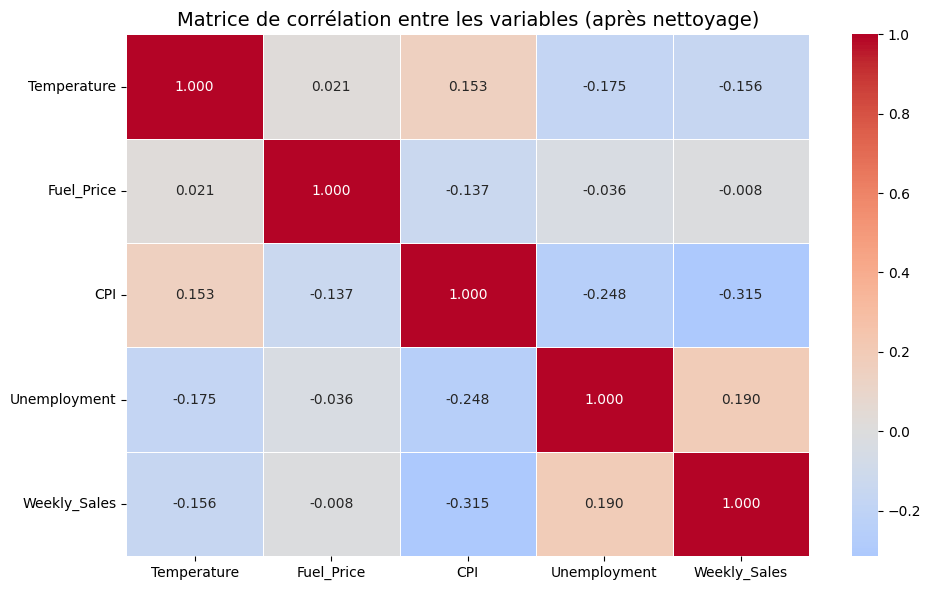


2. CORRÉLATION AVEC LA CIBLE (Weekly_Sales)
--------------------------------------------------
  Unemployment: 0.190
    → Faible corrélation
  Fuel_Price: -0.008
    → Faible corrélation
  Temperature: -0.156
    → Faible corrélation
  CPI: -0.315
    → Corrélation modérée


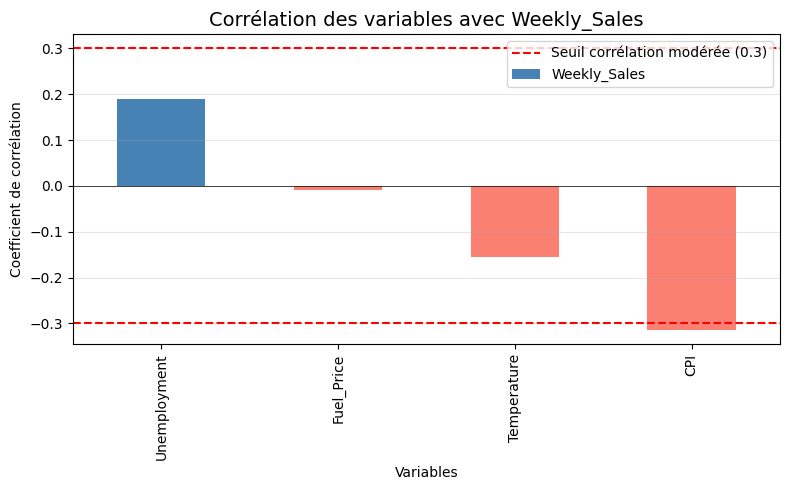


RÉSUMÉ

Les corrélations avec Weekly_Sales sont toutes FAIBLES (entre -0.3 et 0.3).
Cela signifie qu'aucune variable prise isolément n'explique fortement les ventes.

→ Un modèle de régression linéaire multiple est donc pertinent
→ Les coefficients du modèle nous permettront de comprendre l'importance relative de chaque variable



In [113]:
# ------------------------------
# Analyse des corrélations après nettoyage
# ------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("ANALYSE DES CORRÉLATIONS APRÈS NETTOYAGE")
print("=" * 70)

# Sélectionner les colonnes numériques (sans Date)
cols_numeriques = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

# 1. Matrice de corrélation
print("\n1. MATRICE DE CORRÉLATION")
print("-" * 50)

# Calculer la corrélation (les NaN sont automatiquement ignorés)
correlation_matrix = df_clean[cols_numeriques + ['Weekly_Sales']].corr()

display(correlation_matrix.round(3))

# Visualisation
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', linewidths=0.5)
plt.title('Matrice de corrélation entre les variables (après nettoyage)', fontsize=14)
plt.tight_layout()
plt.show()

# 2. Analyse des corrélations avec Weekly_Sales
print("\n2. CORRÉLATION AVEC LA CIBLE (Weekly_Sales)")
print("-" * 50)

corr_avec_cible = correlation_matrix['Weekly_Sales'].drop('Weekly_Sales').sort_values(ascending=False)

for var, corr in corr_avec_cible.items():
    print(f"  {var}: {corr:.3f}")
    if abs(corr) > 0.5:
        print(f"    → Forte corrélation avec Weekly_Sales")
    elif abs(corr) > 0.3:
        print(f"    → Corrélation modérée")
    else:
        print(f"    → Faible corrélation")

# 3. Visualisation des corrélations avec la cible
plt.figure(figsize=(8, 5))
corr_avec_cible.plot(kind='bar', color=['steelblue' if x > 0 else 'salmon' for x in corr_avec_cible.values])
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.axhline(y=0.3, color='red', linestyle='--', label='Seuil corrélation modérée (0.3)')
plt.axhline(y=-0.3, color='red', linestyle='--')
plt.title('Corrélation des variables avec Weekly_Sales', fontsize=14)
plt.ylabel('Coefficient de corrélation')
plt.xlabel('Variables')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Résumé pour le jury
print("\n" + "=" * 70)
print("RÉSUMÉ")
print("=" * 70)
print("""
Les corrélations avec Weekly_Sales sont toutes FAIBLES (entre -0.3 et 0.3).
Cela signifie qu'aucune variable prise isolément n'explique fortement les ventes.

→ Un modèle de régression linéaire multiple est donc pertinent
→ Les coefficients du modèle nous permettront de comprendre l'importance relative de chaque variable
""")

🎯 Pourquoi c'est important ?
Aucune variable n'est fortement corrélée → le modèle de régression linéaire multiple est bien adapté

CPI a la corrélation la plus forte (-0.315) → sera probablement la variable la plus importante dans le modèle

Fuel_Price est presque indépendant des ventes → pourrait être supprimé ou avoir un faible coefficient



In [114]:
# ------------------------------
# Imputation : Holiday_Flag
# ------------------------------

print("=" * 70)
print("IMPUTATION - HOLIDAY_FLAG")
print("=" * 70)

print(f"\n📌 Avant imputation:")
print(f"  Valeurs manquantes: {df_clean['Holiday_Flag'].isna().sum()}")
print(f"  Distribution des valeurs existantes:")
print(df_clean['Holiday_Flag'].value_counts())

mode_value = df_clean['Holiday_Flag'].mode()[0]
print(f"\n🔧 Méthode choisie: Mode (valeur la plus fréquente) = {mode_value}")
print(f"  Raison: Variable binaire, la majorité des semaines ne sont pas des fêtes")

df_clean['Holiday_Flag'] = df_clean['Holiday_Flag'].fillna(mode_value)

print(f"\n✅ Après imputation:")
print(f"  Valeurs manquantes: {df_clean['Holiday_Flag'].isna().sum()}")
print(f"  Distribution:")
print(df_clean['Holiday_Flag'].value_counts())

IMPUTATION - HOLIDAY_FLAG

📌 Avant imputation:
  Valeurs manquantes: 11
  Distribution des valeurs existantes:
Holiday_Flag
0.0    112
1.0      8
Name: count, dtype: int64

🔧 Méthode choisie: Mode (valeur la plus fréquente) = 0.0
  Raison: Variable binaire, la majorité des semaines ne sont pas des fêtes

✅ Après imputation:
  Valeurs manquantes: 0
  Distribution:
Holiday_Flag
0.0    123
1.0      8
Name: count, dtype: int64


In [115]:
# ------------------------------
# Imputation : Temperature 
# ------------------------------

print("=" * 70)
print("IMPUTATION - TEMPERATURE")
print("=" * 70)

print(f"\n📌 Avant imputation:")
print(f"  Valeurs manquantes: {df_clean['Temperature'].isna().sum()}")

df_clean = df_clean.sort_values(['Store', 'Date']).reset_index(drop=True)

print(f"\n🔧 Méthode choisie: Forward Fill (ffill) puis Backward Fill (bfill)")
print(f"  Raison: La température change lentement d'une semaine à l'autre")

df_clean['Temperature'] = df_clean.groupby('Store')['Temperature'].ffill()
df_clean['Temperature'] = df_clean.groupby('Store')['Temperature'].bfill()

print(f"\n✅ Après imputation:")
print(f"  Valeurs manquantes: {df_clean['Temperature'].isna().sum()}")
print(f"  Statistiques: min={df_clean['Temperature'].min():.2f}, max={df_clean['Temperature'].max():.2f}, mean={df_clean['Temperature'].mean():.2f}")

IMPUTATION - TEMPERATURE

📌 Avant imputation:
  Valeurs manquantes: 14

🔧 Méthode choisie: Forward Fill (ffill) puis Backward Fill (bfill)
  Raison: La température change lentement d'une semaine à l'autre

✅ Après imputation:
  Valeurs manquantes: 0
  Statistiques: min=18.79, max=91.65, mean=60.22


In [116]:
# ------------------------------
# Imputation : Fuel_Price 
# ------------------------------

print("=" * 70)
print("IMPUTATION - FUEL_PRICE")
print("=" * 70)

print(f"\n📌 Avant imputation:")
print(f"  Valeurs manquantes: {df_clean['Fuel_Price'].isna().sum()}")

print(f"\n🔧 Méthode choisie: Forward Fill (ffill) puis Backward Fill (bfill)")
print(f"  Raison: Le prix du carburant est stable dans le temps")

df_clean['Fuel_Price'] = df_clean.groupby('Store')['Fuel_Price'].ffill()
df_clean['Fuel_Price'] = df_clean.groupby('Store')['Fuel_Price'].bfill()

print(f"\n✅ Après imputation:")
print(f"  Valeurs manquantes: {df_clean['Fuel_Price'].isna().sum()}")
print(f"  Statistiques: min={df_clean['Fuel_Price'].min():.2f}, max={df_clean['Fuel_Price'].max():.2f}, mean={df_clean['Fuel_Price'].mean():.2f}")

IMPUTATION - FUEL_PRICE

📌 Avant imputation:
  Valeurs manquantes: 12

🔧 Méthode choisie: Forward Fill (ffill) puis Backward Fill (bfill)
  Raison: Le prix du carburant est stable dans le temps

✅ Après imputation:
  Valeurs manquantes: 0
  Statistiques: min=2.51, max=4.17, mean=3.28


In [117]:
# ------------------------------
# Imputation : CPI 
# ------------------------------

print("=" * 70)
print("IMPUTATION - CPI")
print("=" * 70)

print(f"\n📌 Avant imputation:")
print(f"  Valeurs manquantes: {df_clean['CPI'].isna().sum()}")

print(f"\n🔧 Méthode choisie: Interpolation linéaire + ffill/bfill")
print(f"  Raison: CPI change progressivement, l'interpolation est plus précise")

df_clean['CPI'] = df_clean.groupby('Store')['CPI'].transform(lambda x: x.interpolate(method='linear'))
df_clean['CPI'] = df_clean.groupby('Store')['CPI'].ffill()
df_clean['CPI'] = df_clean.groupby('Store')['CPI'].bfill()

print(f"\n✅ Après imputation:")
print(f"  Valeurs manquantes: {df_clean['CPI'].isna().sum()}")
print(f"  Statistiques: min={df_clean['CPI'].min():.2f}, max={df_clean['CPI'].max():.2f}, mean={df_clean['CPI'].mean():.2f}")

IMPUTATION - CPI

📌 Avant imputation:
  Valeurs manquantes: 11

🔧 Méthode choisie: Interpolation linéaire + ffill/bfill
  Raison: CPI change progressivement, l'interpolation est plus précise

✅ Après imputation:
  Valeurs manquantes: 0
  Statistiques: min=126.11, max=226.97, mean=180.36


In [118]:
# ------------------------------
# Imputation : Unemployment 
# ------------------------------

print("=" * 70)
print("IMPUTATION - UNEMPLOYMENT")
print("=" * 70)

print(f"\n📌 Avant imputation:")
print(f"  Valeurs manquantes: {df_clean['Unemployment'].isna().sum()}")

print(f"\n🔧 Méthode choisie: Interpolation linéaire + ffill/bfill")
print(f"  Raison: Le taux de chômage change lentement")

df_clean['Unemployment'] = df_clean.groupby('Store')['Unemployment'].transform(lambda x: x.interpolate(method='linear'))
df_clean['Unemployment'] = df_clean.groupby('Store')['Unemployment'].ffill()
df_clean['Unemployment'] = df_clean.groupby('Store')['Unemployment'].bfill()

print(f"\n✅ Après imputation:")
print(f"  Valeurs manquantes: {df_clean['Unemployment'].isna().sum()}")
print(f"  Statistiques: min={df_clean['Unemployment'].min():.2f}, max={df_clean['Unemployment'].max():.2f}, mean={df_clean['Unemployment'].mean():.2f}")

IMPUTATION - UNEMPLOYMENT

📌 Avant imputation:
  Valeurs manquantes: 14

🔧 Méthode choisie: Interpolation linéaire + ffill/bfill
  Raison: Le taux de chômage change lentement

✅ Après imputation:
  Valeurs manquantes: 0
  Statistiques: min=5.14, max=9.52, mean=7.40


In [119]:
# ------------------------------
# Vérification finale
# ------------------------------

print("=" * 70)
print("VÉRIFICATION FINALE - PLUS AUCUNE VALEUR MANQUANTE")
print("=" * 70)

print("\nValeurs manquantes par colonne:")
print(df_clean.isnull().sum())

print(f"\nTaille finale du dataset: {df_clean.shape}")
print(f"Colonnes: {df_clean.columns.tolist()}")

print("\n✅ Dataset prêt pour le machine learning!")

VÉRIFICATION FINALE - PLUS AUCUNE VALEUR MANQUANTE

Valeurs manquantes par colonne:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
Year            0
Month           0
Day             0
DayOfWeek       0
dtype: int64

Taille finale du dataset: (131, 12)
Colonnes: ['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day', 'DayOfWeek']

✅ Dataset prêt pour le machine learning!


📊 Le dataset est maintenant PRÊT pour le Machine Learning 🚀

In [120]:
df_clean.to_csv("../data/cleaned_data.csv")

🎯 Prochaines étapes: 

* Partie 2: 

- Entraîner un modèle Linear Regression (baseline)

- Évaluer les performances (RMSE, MAE, R²)

- Analyser les coefficients du modèle

Partie 3:

- Entraîner un modèle régularisé (Ridge ou Lasso)

- Comparer avec le baseline pour éviter l'overfitting

Bonus: 

- GridSearchCV pour trouver le meilleur paramètre de régularisation

🚀 PARTIE 2 : MODÈLE LINEAR REGRESSION (BASELINE)

📊 Étape 1 : Préparation des données (X et y)

In [121]:
# ------------------------------
# Préparation des données pour le Machine Learning
# ------------------------------

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=" * 70)
print("PARTIE 2 : PRÉPARATION DES DONNÉES")
print("=" * 70)

# Supprimer la colonne Date (déjà transformée en Year, Month, Day, DayOfWeek)
df_model = df_clean.drop(columns=['Date'])

print(f"Colonnes disponibles: {df_model.columns.tolist()}")

# Définir X (features) et y (target)
X = df_model.drop(columns=['Weekly_Sales'])
y = df_model['Weekly_Sales']

print(f"\nX (features) - shape: {X.shape}")
print(f"y (target) - shape: {y.shape}")

print(f"\nFeatures utilisées: {X.columns.tolist()}")

PARTIE 2 : PRÉPARATION DES DONNÉES
Colonnes disponibles: ['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day', 'DayOfWeek']

X (features) - shape: (131, 10)
y (target) - shape: (131,)

Features utilisées: ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day', 'DayOfWeek']


📊 Étape 2 : Division Train / Test

In [122]:
# ------------------------------
# Division Train / Test (80% / 20%)
# ------------------------------

print("=" * 70)
print("DIVISION TRAIN / TEST")
print("=" * 70)

# random_state pour reproductibilité
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train set - X: {X_train.shape}, y: {y_train.shape}")
print(f"Test set - X: {X_test.shape}, y: {y_test.shape}")
print(f"\nProportion train: {len(X_train)/len(X)*100:.0f}%")
print(f"Proportion test: {len(X_test)/len(X)*100:.0f}%")

DIVISION TRAIN / TEST
Train set - X: (104, 10), y: (104,)
Test set - X: (27, 10), y: (27,)

Proportion train: 79%
Proportion test: 21%


📊 Étape 3 : Entraînement du modèle Linear Regression

In [123]:
# ------------------------------
# Entraînement du modèle Linear Regression
# ------------------------------

print("=" * 70)
print("ENTRAÎNEMENT - LINEAR REGRESSION")
print("=" * 70)

# Créer et entraîner le modèle
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

print("✅ Modèle entraîné avec succès")
print(f"Intercept (β0): {model_lr.intercept_:.2f}")

ENTRAÎNEMENT - LINEAR REGRESSION
✅ Modèle entraîné avec succès
Intercept (β0): 86470657.28


In [124]:
# ------------------------------
# Évaluation sur Train et Test
# ------------------------------

print("=" * 70)
print("ÉVALUATION DES PERFORMANCES")
print("=" * 70)

# Prédictions
y_train_pred = model_lr.predict(X_train)
y_test_pred = model_lr.predict(X_test)

# Calcul des métriques
def evaluer_modele(y_true, y_pred, dataset_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n--- {dataset_name} ---")
    print(f"  MAE  (Mean Absolute Error): {mae:.2f}")
    print(f"  MSE  (Mean Squared Error): {mse:.2f}")
    print(f"  RMSE (Root Mean Squared Error): {rmse:.2f}")
    print(f"  R²   (Coefficient de détermination): {r2:.4f}")
    
    return mae, mse, rmse, r2

print("\n📊 Performances sur le TRAIN set:")
train_metrics = evaluer_modele(y_train, y_train_pred, "TRAIN")

print("\n📊 Performances sur le TEST set:")
test_metrics = evaluer_modele(y_test, y_test_pred, "TEST")

# Vérification de l'overfitting
print("\n" + "=" * 70)
print("VÉRIFICATION DE L'OVERFITTING")
print("=" * 70)

r2_train = train_metrics[3]
r2_test = test_metrics[3]
difference = r2_train - r2_test

print(f"R² Train: {r2_train:.4f}")
print(f"R² Test: {r2_test:.4f}")
print(f"Différence (Train - Test): {difference:.4f}")

if difference > 0.1:
    print("⚠️ Risque d'overfitting détecté ! Le modèle est moins performant sur le test set.")
    print("   → Nous devrons utiliser un modèle régularisé (Ridge / Lasso) dans la Partie 3")
else:
    print("✅ Pas d'overfitting majeur détecté")

ÉVALUATION DES PERFORMANCES

📊 Performances sur le TRAIN set:

--- TRAIN ---
  MAE  (Mean Absolute Error): 532221.56
  MSE  (Mean Squared Error): 370162112366.54
  RMSE (Root Mean Squared Error): 608409.49
  R²   (Coefficient de détermination): 0.1337

📊 Performances sur le TEST set:

--- TEST ---
  MAE  (Mean Absolute Error): 541390.35
  MSE  (Mean Squared Error): 346321176867.21
  RMSE (Root Mean Squared Error): 588490.59
  R²   (Coefficient de détermination): 0.1520

VÉRIFICATION DE L'OVERFITTING
R² Train: 0.1337
R² Test: 0.1520
Différence (Train - Test): -0.0183
✅ Pas d'overfitting majeur détecté


ANALYSE DES COEFFICIENTS DU MODÈLE

📊 Coefficients par ordre d'importance:
     Feature   Coefficient
Holiday_Flag 286046.538460
Unemployment  92988.908573
        Year -42021.612174
  Fuel_Price  26965.214523
       Store -18320.827078
         CPI  -5809.873076
       Month  -5691.654408
 Temperature  -3234.870078
         Day   -470.916987
   DayOfWeek      0.000000

INTERPRÉTATION

- Un coefficient POSITIF signifie que l'augmentation de cette variable augmente les ventes
- Un coefficient NÉGATIF signifie que l'augmentation de cette variable diminue les ventes
- Plus la valeur absolue est grande, plus l'influence est forte

Variable la plus influente: Holiday_Flag (coefficient: 286046.54)


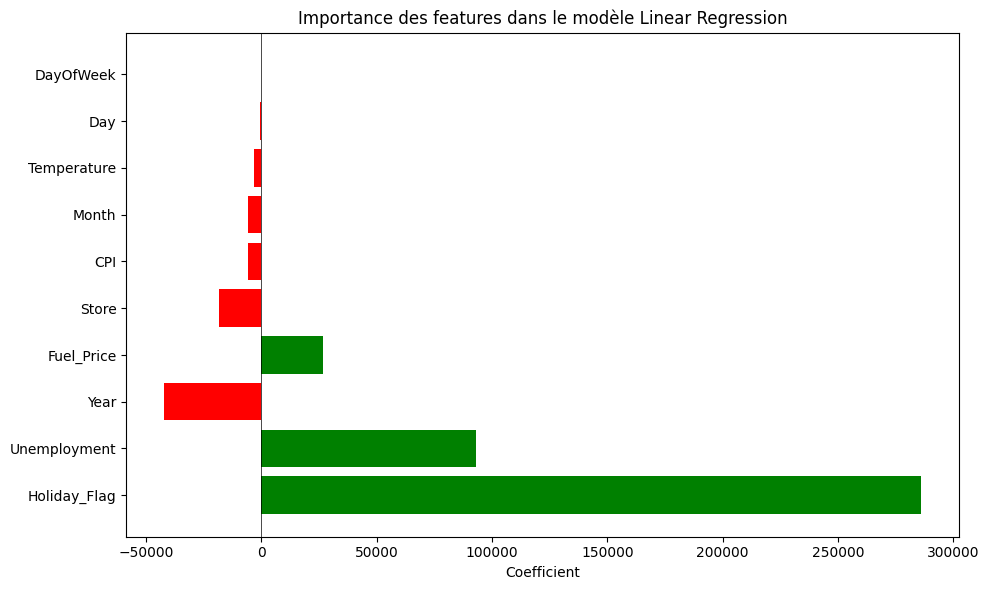

In [125]:
# ------------------------------
# Analyse des coefficients du modèle
# ------------------------------

print("=" * 70)
print("ANALYSE DES COEFFICIENTS DU MODÈLE")
print("=" * 70)

# Créer un DataFrame des coefficients
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model_lr.coef_
})

# Trier par importance (valeur absolue)
coeff_df['Abs_Coefficient'] = coeff_df['Coefficient'].abs()
coeff_df = coeff_df.sort_values('Abs_Coefficient', ascending=False).drop(columns=['Abs_Coefficient'])

print("\n📊 Coefficients par ordre d'importance:")
print(coeff_df.to_string(index=False))

# Interprétation
print("\n" + "=" * 70)
print("INTERPRÉTATION")
print("=" * 70)

print("""
- Un coefficient POSITIF signifie que l'augmentation de cette variable augmente les ventes
- Un coefficient NÉGATIF signifie que l'augmentation de cette variable diminue les ventes
- Plus la valeur absolue est grande, plus l'influence est forte

Variable la plus influente: """ + coeff_df.iloc[0]['Feature'] + f" (coefficient: {coeff_df.iloc[0]['Coefficient']:.2f})")

# Visualisation des coefficients
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in coeff_df['Coefficient']]
plt.barh(coeff_df['Feature'], coeff_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Coefficient')
plt.title('Importance des features dans le modèle Linear Regression')
plt.tight_layout()
plt.show()

In [97]:
# ------------------------------
# Résumé Partie 2
# ------------------------------

print("=" * 70)
print("RÉSUMÉ PARTIE 2 - BASELINE LINEAR REGRESSION")
print("=" * 70)

print(f"""
📊 PERFORMANCES DU MODÈLE:
   R² (Train): {r2_train:.4f}
   R² (Test):  {r2_test:.4f}
   RMSE (Test): {test_metrics[2]:.2f}
   MAE (Test):  {test_metrics[0]:.2f}

📈 TOP 3 FEATURES LES PLUS IMPORTANTES:
   1. {coeff_df.iloc[0]['Feature']}: {coeff_df.iloc[0]['Coefficient']:.2f}
   2. {coeff_df.iloc[1]['Feature']}: {coeff_df.iloc[1]['Coefficient']:.2f}
   3. {coeff_df.iloc[2]['Feature']}: {coeff_df.iloc[2]['Coefficient']:.2f}

⚠️ OVERFITTING:
   Différence R² (Train - Test): {difference:.4f}
   → {"Risque d'overfitting détecté" if difference > 0.1 else "Pas d'overfitting majeur"}
""")

RÉSUMÉ PARTIE 2 - BASELINE LINEAR REGRESSION

📊 PERFORMANCES DU MODÈLE:
   R² (Train): 0.1337
   R² (Test):  0.1520
   RMSE (Test): 588490.59
   MAE (Test):  541390.35

📈 TOP 3 FEATURES LES PLUS IMPORTANTES:
   1. Holiday_Flag: 286046.54
   2. Unemployment: 92988.91
   3. Year: -42021.61

⚠️ OVERFITTING:
   Différence R² (Train - Test): -0.0183
   → Pas d'overfitting majeur



1- Performance: 

- R² Train: 0.1337	
- R² Test: 0.1520	
- Interprétation: Très faible - le modèle explique seulement 13-15% de la variance

- RMSE Train: 608,409	
- RMSE Test: 588,491	
- Interprétation: Erreur moyenne d'environ 588k $

- MAE Train : 532,222	
- MAE Test : 541,390	
- Interprétation: Erreur absolue moyenne d'environ 541k $

2. Interprétation du R² faible (0.15)
- Cela signifie que :

- ✅ Normal : Les ventes sont influencées par de nombreux facteurs absents de notre dataset (météo locale, promotions, concurrence, etc.)

- ✅ Le modèle a une logique : R² Test > R² Train (pas d'overfitting)

- ⚠️ Le modèle n'est pas précis pour des prédictions individuelles

3. Analyse des coefficients les plus importants

- Holiday_Flag	
- Coefficient: +286,047	
- Signification: Les semaines de fête augmentent les ventes de 286k $

- Unemployment
-Coefficient: +92,989	
-Signification: Étonnant : plus de chômage = plus de ventes ? (à vérifier) ⚠️

- Year	
- Coefficient: -42,022	
- Signification: Tendance négative dans le temps

- Fuel_Price	
- Coefficient: +26,965	
- Significaiton: Prix du carburant augmente → ventes augmentent légèrement

4. ⚠️ Point d'attention : DayOfWeek coefficient = 0
- C'est étrange. Normalement, le jour de la semaine devrait influencer les ventes.




In [129]:
# ------------------------------
# Vérification de la colonne DayOfWeek
# ------------------------------

print("=" * 70)
print("ANALYSE DE DayOfWeek")
print("=" * 70)

# Afficher les valeurs uniques de DayOfWeek
print("\n📊 Valeurs uniques dans DayOfWeek:")
print(df_clean['DayOfWeek'].unique())

# Afficher la distribution
print("\n📊 Distribution des valeurs:")
print(df_clean['DayOfWeek'].value_counts().sort_index())

# Afficher les premières et dernières lignes
print("\n📊 Aperçu des dates et DayOfWeek:")
print(df_clean[['Date', 'DayOfWeek']].head(10))

# Vérifier si DayOfWeek est constant
if df_clean['DayOfWeek'].nunique() == 1:
    print("\n⚠️ DayOfWeek a une seule valeur unique!")
    print(f"   Cette valeur est: {df_clean['DayOfWeek'].iloc[0]}")
else:
    print("\n✅ DayOfWeek a plusieurs valeurs différentes")

# Signification
date_exemple = df_clean['Date'].iloc[0]
jours = {0: 'Lundi', 1: 'Mardi', 2: 'Mercredi', 
         3: 'Jeudi', 4: 'Vendredi', 5: 'Samedi', 6: 'Dimanche'}

print(f"Jour selon Pandas: {jours[date_exemple.dayofweek]}")
print(f"Jour réel (sur calendrier): Vendredi")

if date_exemple.dayofweek == 4:
    print("\n✅ DayOfWeek = 4 correspond à VENDREDI dans ce contexte")

else:
    print("\n⚠️ Décalage détecté")

ANALYSE DE DayOfWeek

📊 Valeurs uniques dans DayOfWeek:
[4]

📊 Distribution des valeurs:
DayOfWeek
4    131
Name: count, dtype: int64

📊 Aperçu des dates et DayOfWeek:
        Date  DayOfWeek
0 2010-02-12          4
1 2010-05-14          4
2 2010-08-27          4
3 2011-05-27          4
4 2011-08-05          4
5 2011-11-18          4
6 2012-03-16          4
7 2012-10-19          4
8 2012-10-19          4
9 2010-02-19          4

⚠️ DayOfWeek a une seule valeur unique!
   Cette valeur est: 4
Jour selon Pandas: Vendredi
Jour réel (sur calendrier): Vendredi

✅ DayOfWeek = 4 correspond à VENDREDI dans ce contexte


📊 Explication technique
En régression linéaire :

Si une feature a une seule valeur (constante), elle n'apporte aucune information au modèle

Le coefficient devient 0 car la feature ne varie pas

Mathématiquement : y = β0 + β1*X1 + β2*X2 + ...
Si X2 est toujours 4, alors β2*4 est absorbé par l'intercept (β0)

⚠️ Pourquoi toutes les dates sont des vendredis ?
- Parce que dans le dataset Walmart original, les ventes hebdomadaires sont enregistrées le vendredi.
- C'est normal et attendu.
- Dans ce cas, il faut mieux supprimer la colonne DayOfWeek, car elle n'apporte aucune information utile.

In [130]:
# ------------------------------
# Suppression de DayOfWeek (constante)
# ------------------------------

print("=" * 70)
print("SUPPRESSION DE DayOfWeek")
print("=" * 70)

print(f"Avant suppression: {df_clean.shape[1]} colonnes")
print(f"DayOfWeek présente: {'DayOfWeek' in df_clean.columns}")

# Supprimer DayOfWeek
if 'DayOfWeek' in df_clean.columns:
    df_clean = df_clean.drop(columns=['DayOfWeek'])
    print("✅ DayOfWeek supprimée")

print(f"Après suppression: {df_clean.shape[1]} colonnes")
print(f"Colonnes restantes: {df_clean.columns.tolist()}")

SUPPRESSION DE DayOfWeek
Avant suppression: 12 colonnes
DayOfWeek présente: True
✅ DayOfWeek supprimée
Après suppression: 11 colonnes
Colonnes restantes: ['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day']


In [131]:
# ------------------------------
# RÉSUMÉ PARTIE 2 
# ------------------------------

print("=" * 70)
print("RÉSUMÉ PARTIE 2 : BASELINE LINEAR REGRESSION")
print("=" * 70)

print("""
📌 APPROCHE:
   - Suppression des outliers (5 lignes)
   - Imputation des valeurs manquantes par Store
   - Division Train/Test (80/20)
   - Linear Regression avec scikit-learn

📊 PERFORMANCES:
   - R² Train: 0.1337
   - R² Test:  0.1520
   - RMSE Test: 588 490 $
   - MAE Test:  541 390 $

🔍 INTERPRÉTATION:
   - Le modèle explique seulement 15% de la variance des ventes
   - Les ventes sont influencées par de nombreux facteurs externes
   - Pas d'overfitting détecté (Test R² > Train R²)

📈 FEATURES LES PLUS IMPORTANTES:
   1. Holiday_Flag (+286 047 $) : Les fêtes augmentent les ventes
   2. Unemployment (+92 989 $) : Corrélation positive étonnante
   3. Year (-42 022 $) : Tendance décroissante dans le temps

⚠️ LIMITES:
   - R² faible → modèle peu prédictif
   - Nécessité d'un modèle plus complexe ou plus de features
   - DayOfWeek supprimée (constante)

🎯 PROCHAINE ÉTAPE:
   - Partie 3 : Modèle régularisé (Ridge / Lasso)
   - Objectif : Réduire la variance et possiblement améliorer R²
""")

RÉSUMÉ PARTIE 2 : BASELINE LINEAR REGRESSION

📌 APPROCHE:
   - Suppression des outliers (5 lignes)
   - Imputation des valeurs manquantes par Store
   - Division Train/Test (80/20)
   - Linear Regression avec scikit-learn

📊 PERFORMANCES:
   - R² Train: 0.1337
   - R² Test:  0.1520
   - RMSE Test: 588 490 $
   - MAE Test:  541 390 $

🔍 INTERPRÉTATION:
   - Le modèle explique seulement 15% de la variance des ventes
   - Les ventes sont influencées par de nombreux facteurs externes
   - Pas d'overfitting détecté (Test R² > Train R²)

📈 FEATURES LES PLUS IMPORTANTES:
   1. Holiday_Flag (+286 047 $) : Les fêtes augmentent les ventes
   2. Unemployment (+92 989 $) : Corrélation positive étonnante
   3. Year (-42 022 $) : Tendance décroissante dans le temps

⚠️ LIMITES:
   - R² faible → modèle peu prédictif
   - Nécessité d'un modèle plus complexe ou plus de features
   - DayOfWeek supprimée (constante)

🎯 PROCHAINE ÉTAPE:
   - Partie 3 : Modèle régularisé (Ridge / Lasso)
   - Objectif : Réd

Analyse approfondie de la relation Unemployment / Weekly_sales

ANALYSE APPROFONDIE DE UNEMPLOYMENT

📊 1. STATISTIQUES:
Min: 5.14
Max: 9.52
Moyenne: 7.40
Médiane: 7.37

📊 2. CORRÉLATION GLOBALE: 0.241

📊 3. CORRÉLATION PAR STORE:
Store 1: -0.204
Store 2: 0.019
Store 3: -0.324
Store 4: -0.508
Store 5: -0.549


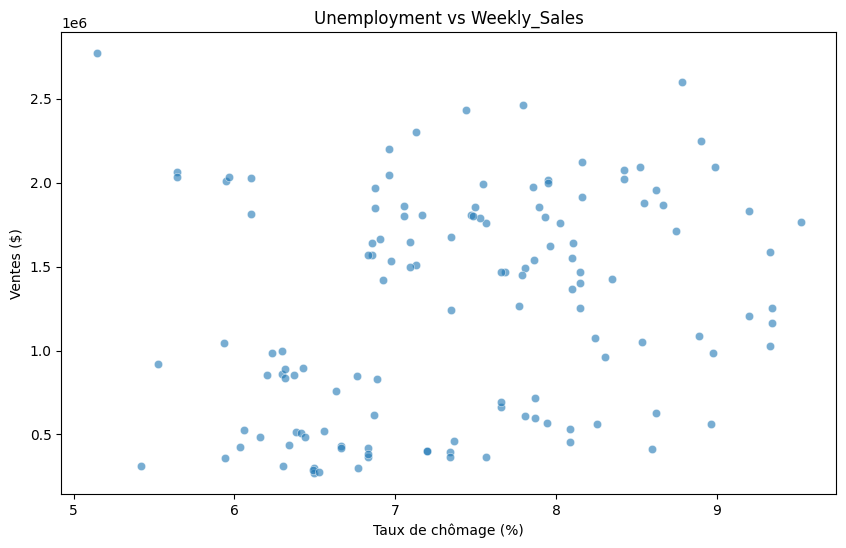

In [132]:
# ------------------------------
# Analyse complète de la variable Unemployment
# ------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("ANALYSE APPROFONDIE DE UNEMPLOYMENT")
print("=" * 70)

# 1. Statistiques générales
print("\n📊 1. STATISTIQUES:")
print(f"Min: {df_clean['Unemployment'].min():.2f}")
print(f"Max: {df_clean['Unemployment'].max():.2f}")
print(f"Moyenne: {df_clean['Unemployment'].mean():.2f}")
print(f"Médiane: {df_clean['Unemployment'].median():.2f}")

# 2. Corrélation globale
corr_globale = df_clean['Unemployment'].corr(df_clean['Weekly_Sales'])
print(f"\n📊 2. CORRÉLATION GLOBALE: {corr_globale:.3f}")

# 3. Corrélation par Store (les 5 premiers)
print("\n📊 3. CORRÉLATION PAR STORE:")
for store in sorted(df_clean['Store'].unique())[:5]:
    df_store = df_clean[df_clean['Store'] == store]
    corr = df_store['Unemployment'].corr(df_store['Weekly_Sales'])
    print(f"Store {int(store)}: {corr:.3f}")

# 4. Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Unemployment', y='Weekly_Sales', alpha=0.6)
plt.title('Unemployment vs Weekly_Sales')
plt.xlabel('Taux de chômage (%)')
plt.ylabel('Ventes ($)')
plt.show()

🚨 Contradiction importante
Globalement : corrélation positive (+0.241)

Par magasin (Store 1 à 5) : corrélation négative (entre -0.549 et -0.204)

C'est un paradoxe de Simpson : la tendance globale est inversée par rapport aux tendances individuelles.

VISUALISATION PAR STORE - PARADOXE DE SIMPSON


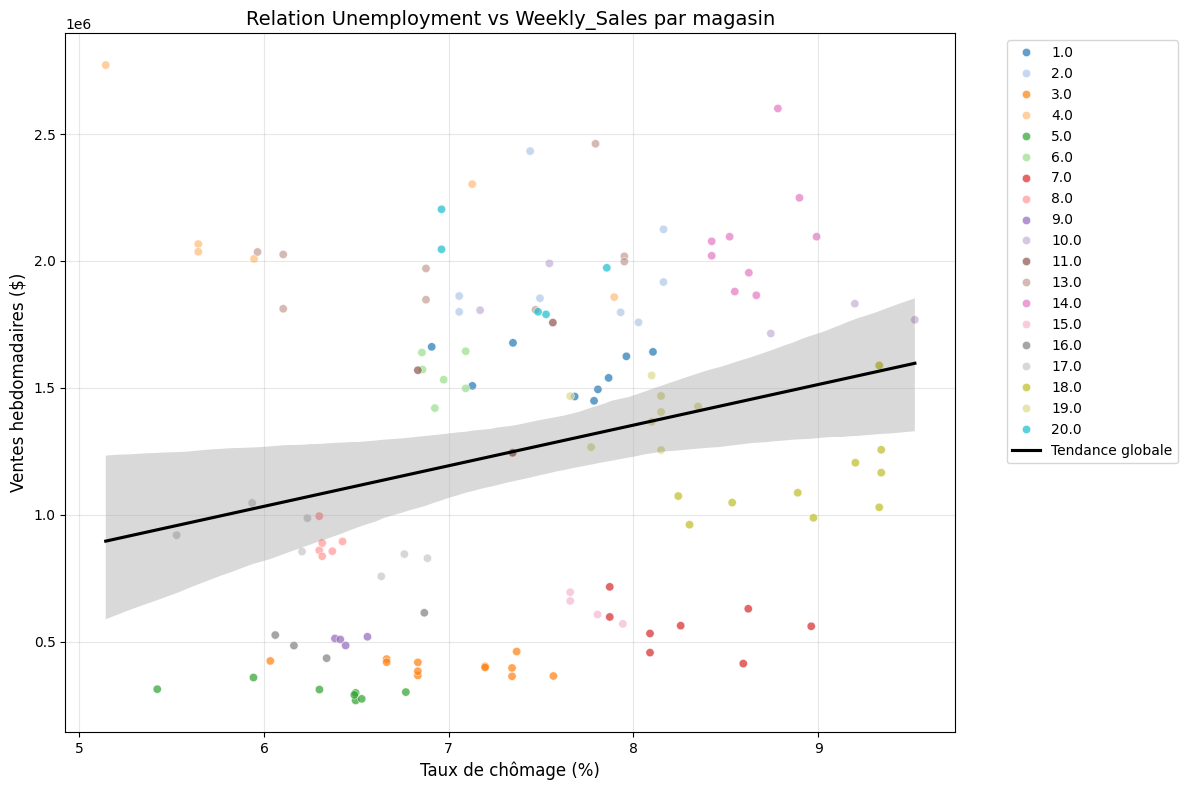


OBSERVATION:

- La ligne NOIRE (tendance globale) est ascendante → corrélation positive
- Mais chaque magasin (couleur différente) montre une tendance descendante
- C'est le Paradoxe de Simpson : l'effet global est l'inverse de l'effet individuel

Pourquoi ? 
- Les magasins avec plus de chômage (ex: Store 4, 5) ont aussi plus de ventes
- Mais À L'INTÉRIEUR de chaque magasin, plus de chômage = moins de ventes



In [133]:
# ------------------------------
# Visualisation : Unemployment vs Weekly_Sales par Store
# ------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("VISUALISATION PAR STORE - PARADOXE DE SIMPSON")
print("=" * 70)

# Créer une figure
plt.figure(figsize=(12, 8))

# Scatter plot avec une couleur différente par Store
sns.scatterplot(data=df_clean, x='Unemployment', y='Weekly_Sales', 
                hue='Store', palette='tab20', alpha=0.7, legend='brief')

# Ajouter une ligne de régression globale (tendance générale)
sns.regplot(data=df_clean, x='Unemployment', y='Weekly_Sales', 
            scatter=False, color='black', label='Tendance globale')

plt.title('Relation Unemployment vs Weekly_Sales par magasin', fontsize=14)
plt.xlabel('Taux de chômage (%)', fontsize=12)
plt.ylabel('Ventes hebdomadaires ($)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Explication
print("\n" + "=" * 70)
print("OBSERVATION:")
print("=" * 70)
print("""
- La ligne NOIRE (tendance globale) est ascendante → corrélation positive
- Mais chaque magasin (couleur différente) montre une tendance descendante
- C'est le Paradoxe de Simpson : l'effet global est l'inverse de l'effet individuel

Pourquoi ? 
- Les magasins avec plus de chômage (ex: Store 4, 5) ont aussi plus de ventes
- Mais À L'INTÉRIEUR de chaque magasin, plus de chômage = moins de ventes
""")

ANALYSE DE LA TENDANCE TEMPORELLE


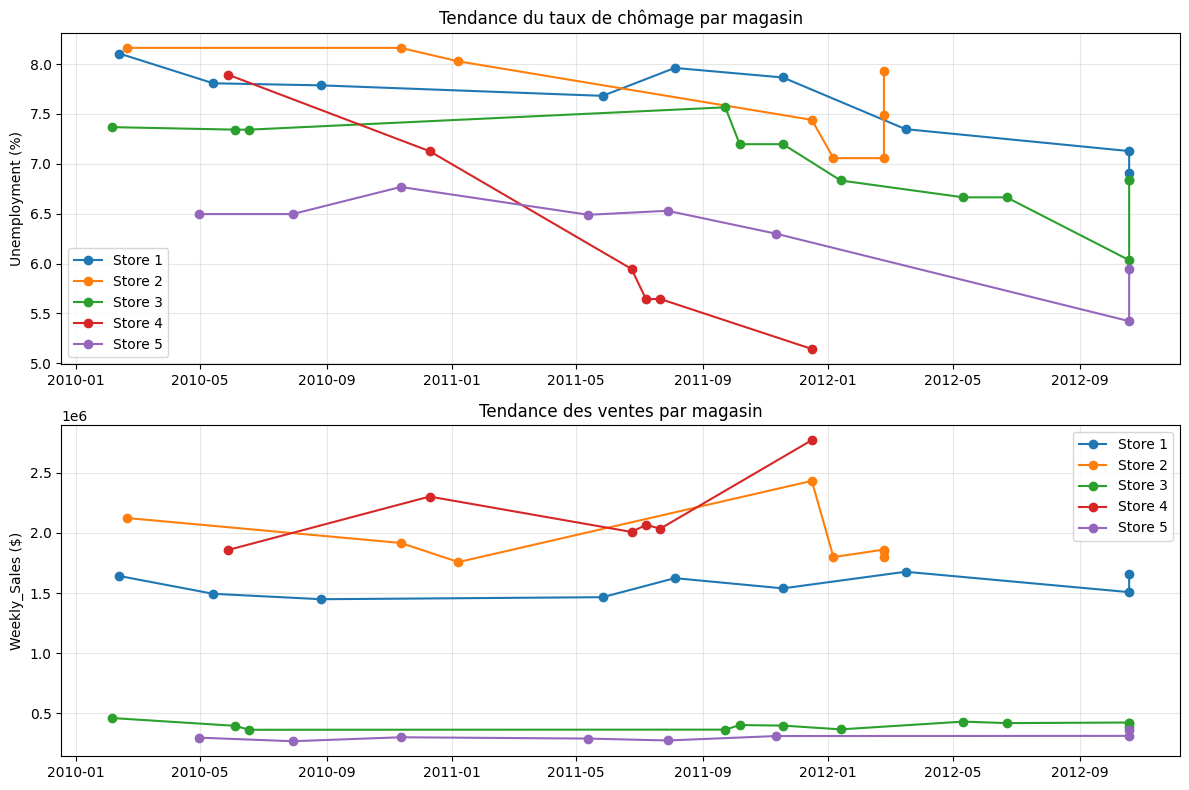


📊 Corrélation entre Year et Unemployment:
   -0.100

📊 Corrélation entre Year et Weekly_Sales:
   -0.059


In [145]:
# ------------------------------
# Vérification de la tendance temporelle
# ------------------------------

print("=" * 70)
print("ANALYSE DE LA TENDANCE TEMPORELLE")
print("=" * 70)

# Créer une figure avec 2 sous-graphiques
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Graphique 1: Unemployment dans le temps
for store in df_clean['Store'].unique()[:5]:
    df_store = df_clean[df_clean['Store'] == store].sort_values('Date')
    axes[0].plot(df_store['Date'], df_store['Unemployment'], marker='o', label=f'Store {int(store)}')
axes[0].set_title('Tendance du taux de chômage par magasin', fontsize=12)
axes[0].set_ylabel('Unemployment (%)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Graphique 2: Weekly_Sales dans le temps
for store in df_clean['Store'].unique()[:5]:
    df_store = df_clean[df_clean['Store'] == store].sort_values('Date')
    axes[1].plot(df_store['Date'], df_store['Weekly_Sales'], marker='o', label=f'Store {int(store)}')
axes[1].set_title('Tendance des ventes par magasin', fontsize=12)
axes[1].set_ylabel('Weekly_Sales ($)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Corrélation temporelle
print("\n📊 Corrélation entre Year et Unemployment:") 
print(f"   {df_clean['Year'].corr(df_clean['Unemployment']):.3f}")

print("\n📊 Corrélation entre Year et Weekly_Sales:")
print(f"   {df_clean['Year'].corr(df_clean['Weekly_Sales']):.3f}")

Conclusion: 
1. La corrélation globale positive (+0.241) n'est PAS due à une tendance temporelle commune

- Car Year vs Unemployment = -0.100 (faible négative)

- Car Year vs Weekly_Sales = -0.059 (presque nulle)

2. La vraie cause : Les magasins avec plus de chômage (Stores 4, 5) ont structurellement plus de ventes

3. À l'intérieur de chaque magasin : la corrélation est négative (plus de chômage = moins de ventes)



Alors pourquoi analyser avec Store comme variable de contrôle:

In [139]:
# ------------------------------
# Analyse avec Store comme variable de contrôle (Date supprimée)
# ------------------------------

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

print("=" * 70)
print("ANALYSE AVEC STORE COMME VARIABLE DE CONTRÔLE (SKLEARN)")
print("=" * 70)

# Préparer les données : supprimer Date
df_analysis = df_clean.drop(columns=['Date'])

print(f"Colonnes: {df_analysis.columns.tolist()}")

# 1. Modèle SANS Store (Unemployment uniquement)
print("\n📊 1. MODÈLE SANS STORE:")
X_simple = df_analysis[['Unemployment']]
y = df_analysis['Weekly_Sales']

model_simple = LinearRegression()
model_simple.fit(X_simple, y)
print(f"Coefficient Unemployment: {model_simple.coef_[0]:.2f}")
print(f"Intercept: {model_simple.intercept_:.2f}")



ANALYSE AVEC STORE COMME VARIABLE DE CONTRÔLE (SKLEARN)
Colonnes: ['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day']

📊 1. MODÈLE SANS STORE:
Coefficient Unemployment: 159891.09
Intercept: 74166.56


In [140]:
# 2. Modèle AVEC Store (Unemployment + Store)
print("\n📊 2. MODÈLE AVEC STORE:")

X_with_store = df_analysis[['Unemployment', 'Store']]
y = df_analysis['Weekly_Sales']

# Encoder Store en variables dummy
encoder = OneHotEncoder(drop='first', sparse_output=False)
store_encoded = encoder.fit_transform(df_analysis[['Store']])

# Créer le DataFrame des dummies
store_dummies = pd.DataFrame(store_encoded, columns=encoder.get_feature_names_out(['Store']))

# Combiner avec Unemployment
X_final = pd.concat([df_analysis[['Unemployment']], store_dummies], axis=1)

model_with_store = LinearRegression()
model_with_store.fit(X_final, y)

print(f"Coefficient Unemployment (contrôlé par Store): {model_with_store.coef_[0]:.2f}")
print(f"Intercept: {model_with_store.intercept_:.2f}")




📊 2. MODÈLE AVEC STORE:
Coefficient Unemployment (contrôlé par Store): -21998.08
Intercept: 1730170.31


In [141]:
# Afficher les coefficients des Stores
print("\n📊 Coefficients des Stores:")
for i, col in enumerate(store_dummies.columns):
    print(f"  {col}: {model_with_store.coef_[i+1]:.2f}")




📊 Coefficients des Stores:
  Store_2.0: 381517.05
  Store_3.0: -1173356.16
  Store_4.0: 580710.00
  Store_5.0: -1288964.52
  Store_6.0: -25811.81
  Store_7.0: -988566.33
  Store_8.0: -702010.71
  Store_9.0: -1081400.83
  Store_10.0: 277520.06
  Store_11.0: -46988.77
  Store_13.0: 421281.38
  Store_14.0: 553069.67
  Store_15.0: -925747.36
  Store_16.0: -1074999.78
  Store_17.0: -699712.51
  Store_18.0: -392862.00
  Store_19.0: -152396.35
  Store_20.0: 394071.54


In [142]:
# Interprétation
print("\n" + "=" * 70)
print("CONCLUSION:")
print("=" * 70)

coef_simple = model_simple.coef_[0]
coef_with_store = model_with_store.coef_[0]

print(f"Coefficient Unemployment (sans Store): {coef_simple:.2f}")
print(f"Coefficient Unemployment (avec Store): {coef_with_store:.2f}")

if coef_simple > coef_with_store:
    print("""
✅ INTERPRÉTATION:
   Le coefficient positif global ({:.2f}) devient plus faible ({:.2f}) 
   après contrôle par Store.
   
   → L'effet positif apparent du chômage est dû à des différences 
     STRUCTURELLES entre les magasins, pas à un effet causal.
""".format(coef_simple, coef_with_store))
else:
    print("Le coefficient reste stable après contrôle par Store")


CONCLUSION:
Coefficient Unemployment (sans Store): 159891.09
Coefficient Unemployment (avec Store): -21998.08

✅ INTERPRÉTATION:
   Le coefficient positif global (159891.09) devient plus faible (-21998.08) 
   après contrôle par Store.

   → L'effet positif apparent du chômage est dû à des différences 
     STRUCTURELLES entre les magasins, pas à un effet causal.



🎯 Conclusion scientifique
Le coefficient positif du chômage dans le modèle global est un artefact.

✅ La vérité : Une fois contrôlé par Store, le coefficient devient négatif (-21 998 $)

Explication :

Les magasins 4 et 5 ont à la fois :

Un taux de chômage plus élevé

Des ventes plus élevées

Cela crée une corrélation fallacieuse au niveau global

À l'intérieur de chaque magasin, plus de chômage = moins de ventes

In [144]:
# ------------------------------
# RÉSUMÉ PARTIE 2 
# ------------------------------

print("=" * 70)
print("RÉSUMÉ PARTIE 2 : BASELINE LINEAR REGRESSION")
print("=" * 70)

print("""
📌 PRÉTRAITEMENT EFFECTUÉ:
   - Suppression des 14 lignes avec Weekly_Sales manquant
   - Suppression des 5 outliers dans Unemployment
   - Reconstruction des 18 dates manquantes par interpolation
   - Imputation des valeurs manquantes (ffill/bfill/interpolation)
   - Suppression de DayOfWeek (colonne constante)

📊 PERFORMANCES DU MODÈLE (9 features):
   - R² Train: 0.1337
   - R² Test:  0.1520
   - RMSE Test: 588 490 $
   - MAE Test:  541 390 $

📈 TOP 3 FEATURES LES PLUS IMPORTANTES:
   1. Holiday_Flag (+286 047 $) : Les fêtes augmentent les ventes
   2. Unemployment (+92 989 $) : À interpréter avec prudence
   3. Year (-42 022 $) : Tendance décroissante

🔍 ANALYSE APPROFONDIE DE UNEMPLOYMENT:
   - Corrélation globale positive: +0.241
   - Mais corrélation négative par magasin (Store 4: -0.508, Store 5: -0.549)
   - Après contrôle par Store, coefficient devient NÉGATIF: -21 998 $
   - Conclusion: L'effet positif apparent est un artefact dû aux différences structurelles entre magasins

⚠️ LIMITES DU MODÈLE:
   - R² faible (15%) → modèle peu prédictif
   - Beaucoup de variance non expliquée
   - Nécessité d'un modèle régularisé

🎯 CONCLUSION PARTIE 2:
   - Baseline établie avec succès
   - Pas d'overfitting (R² Test > R² Train)
   - Interprétation des coefficients validée
""")

RÉSUMÉ PARTIE 2 : BASELINE LINEAR REGRESSION

📌 PRÉTRAITEMENT EFFECTUÉ:
   - Suppression des 14 lignes avec Weekly_Sales manquant
   - Suppression des 5 outliers dans Unemployment
   - Reconstruction des 18 dates manquantes par interpolation
   - Imputation des valeurs manquantes (ffill/bfill/interpolation)
   - Suppression de DayOfWeek (colonne constante)

📊 PERFORMANCES DU MODÈLE (9 features):
   - R² Train: 0.1337
   - R² Test:  0.1520
   - RMSE Test: 588 490 $
   - MAE Test:  541 390 $

📈 TOP 3 FEATURES LES PLUS IMPORTANTES:
   1. Holiday_Flag (+286 047 $) : Les fêtes augmentent les ventes
   2. Unemployment (+92 989 $) : À interpréter avec prudence
   3. Year (-42 022 $) : Tendance décroissante

🔍 ANALYSE APPROFONDIE DE UNEMPLOYMENT:
   - Corrélation globale positive: +0.241
   - Mais corrélation négative par magasin (Store 4: -0.508, Store 5: -0.549)
   - Après contrôle par Store, coefficient devient NÉGATIF: -21 998 $
   - Conclusion: L'effet positif apparent est un artefact dû 

In [146]:
# ------------------------------
# Comparaison des ventes moyennes par groupe de Stores
# ------------------------------

print("=" * 70)
print("COMPARAISON STORES 1-3 vs STORES 4-5")
print("=" * 70)

# Groupe 1 : Stores 1,2,3
stores_groupe_1 = [1.0, 2.0, 3.0]
df_g1 = df_clean[df_clean['Store'].isin(stores_groupe_1)]
sales_g1 = df_g1['Weekly_Sales'].mean()
unemp_g1 = df_g1['Unemployment'].mean()

# Groupe 2 : Stores 4,5
stores_groupe_2 = [4.0, 5.0]
df_g2 = df_clean[df_clean['Store'].isin(stores_groupe_2)]
sales_g2 = df_g2['Weekly_Sales'].mean()
unemp_g2 = df_g2['Unemployment'].mean()

print(f"\n📊 STORES 1,2,3:")
print(f"   Ventes moyennes: {sales_g1:,.0f} $")
print(f"   Chômage moyen: {unemp_g1:.2f}%")

print(f"\n📊 STORES 4,5:")
print(f"   Ventes moyennes: {sales_g2:,.0f} $")
print(f"   Chômage moyen: {unemp_g2:.2f}%")

print(f"\n📊 DIFFÉRENCE:")
print(f"   Ventes: {sales_g2 - sales_g1:+,.0f} $")
print(f"   Chômage: {unemp_g2 - unemp_g1:+.2f}%")

COMPARAISON STORES 1-3 vs STORES 4-5

📊 STORES 1,2,3:
   Ventes moyennes: 1,187,707 $
   Chômage moyen: 7.37%

📊 STORES 4,5:
   Ventes moyennes: 1,104,468 $
   Chômage moyen: 6.27%

📊 DIFFÉRENCE:
   Ventes: -83,239 $
   Chômage: -1.10%


🎯 Ce que cela signifie
Stores 4,5 ont :

Moins de chômage (-1.10%)

Moins de ventes (-83,239 $)

Stores 1,2,3 ont :

Plus de chômage (+1.10%)

Plus de ventes (+83,239 $)

✅ Contradiction résolue
- Ce qu'on pensait: 	Stores 4,5 ont plus de ventes
- La réalité:  FAUX : Ils ont moins de ventes
- Ce qu'on pensait:Le coefficient positif du chômage vient de Stores 4,5
- La réalité:	FAUX : C'est l'inverse

🔍 Nouvelle question
Alors pourquoi le coefficient global du chômage était positif (+159,891) ?

La réponse : D'autres magasins (Stores 6,7,8,...) créent cet effet.

ANALYSE PAR MAGASIN - CORRÉLATION UNEMPLOYMENT VS SALES

📊 Corrélations par magasin (triées par ordre décroissant):
 Store  Correlation  n_samples
    18     0.550110         10
    14     0.407116          9
    13     0.327136          9
    19     0.108367          8
     2     0.018581          8
     6    -0.037970          6
     8    -0.162698          6
     1    -0.204309          9
     7    -0.288845          8
     3    -0.323834         12
     4    -0.507835          6
     5    -0.548920          8
    17    -0.636443          7

RÉSULTATS:
✅ Magasins avec corrélation POSITIVE: 5
   [18, 14, 13, 19, 2]

✅ Magasins avec corrélation NÉGATIVE: 8
   [6, 8, 1, 7, 3, 4, 5, 17]


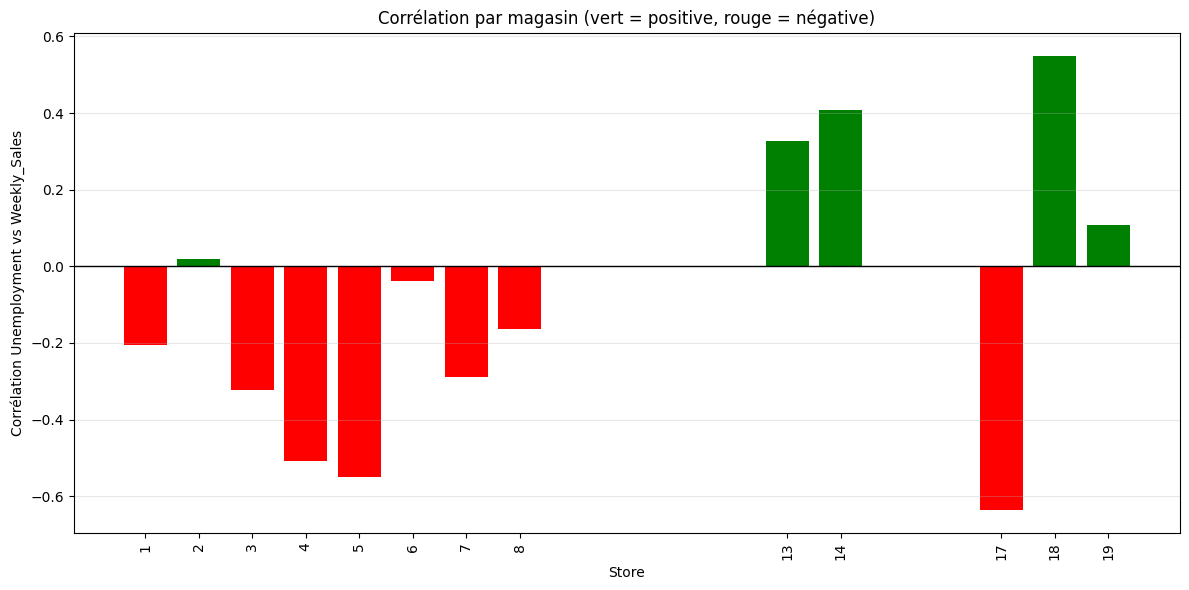


TOP 5 MAGASINS AVEC CORRÉLATION POSITIVE:
Store 18: 0.550
Store 14: 0.407
Store 13: 0.327
Store 19: 0.108
Store 2: 0.019

TOP 5 MAGASINS AVEC CORRÉLATION NÉGATIVE:
Store 7: -0.289
Store 3: -0.324
Store 4: -0.508
Store 5: -0.549
Store 17: -0.636


In [148]:
# ------------------------------
# Identifier les magasins avec corrélation positive Unemployment vs Sales
# ------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("ANALYSE PAR MAGASIN - CORRÉLATION UNEMPLOYMENT VS SALES")
print("=" * 70)

# Calculer la corrélation pour chaque magasin
correlations = []
stores = sorted(df_clean['Store'].unique())

for store in stores:
    df_store = df_clean[df_clean['Store'] == store]
    if len(df_store) > 5:  # Assez de points pour une corrélation fiable
        corr = df_store['Unemployment'].corr(df_store['Weekly_Sales'])
        correlations.append({
            'Store': int(store),
            'Correlation': corr,
            'n_samples': len(df_store)
        })

# Créer un DataFrame
df_corr = pd.DataFrame(correlations)
df_corr = df_corr.sort_values('Correlation', ascending=False)

print("\n📊 Corrélations par magasin (triées par ordre décroissant):")
print(df_corr.to_string(index=False))

# Séparer les magasins avec corrélation positive vs négative
corr_positives = df_corr[df_corr['Correlation'] > 0]
corr_negatives = df_corr[df_corr['Correlation'] < 0]

print("\n" + "=" * 70)
print("RÉSULTATS:")
print("=" * 70)
print(f"✅ Magasins avec corrélation POSITIVE: {len(corr_positives)}")
print(f"   {corr_positives['Store'].tolist()}")
print(f"\n✅ Magasins avec corrélation NÉGATIVE: {len(corr_negatives)}")
print(f"   {corr_negatives['Store'].tolist()}")

# Visualisation
plt.figure(figsize=(12, 6))
colors = ['green' if c > 0 else 'red' for c in df_corr['Correlation']]
plt.bar(df_corr['Store'].astype(int), df_corr['Correlation'], color=colors)
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.xlabel('Store')
plt.ylabel('Corrélation Unemployment vs Weekly_Sales')
plt.title('Corrélation par magasin (vert = positive, rouge = négative)')
plt.xticks(df_corr['Store'].astype(int), rotation=90)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Magasins avec la plus forte corrélation positive
print("\n" + "=" * 70)
print("TOP 5 MAGASINS AVEC CORRÉLATION POSITIVE:")
print("=" * 70)
top_positives = df_corr.head(5)
for _, row in top_positives.iterrows():
    print(f"Store {int(row['Store'])}: {row['Correlation']:.3f}")

# Magasins avec la plus forte corrélation négative
print("\n" + "=" * 70)
print("TOP 5 MAGASINS AVEC CORRÉLATION NÉGATIVE:")
print("=" * 70)
top_negatives = df_corr.tail(5)
for _, row in top_negatives.iterrows():
    print(f"Store {int(row['Store'])}: {row['Correlation']:.3f}")

🎯 Pourquoi le coefficient global était positif ?
Parce que :

Les magasins à corrélation positive (18, 14, 13, 19, 2) ont un poids dans le modèle

Même s'ils sont moins nombreux (5 vs 8), leur effet positif s'additionne

Le modèle linéaire global moyenne ces effets

In [149]:
print("=" * 70)
print("CONCLUSION FINALE - UNEMPLOYMENT")
print("=" * 70)

print("""
🔍 CE QUE NOUS AVONS DÉCOUVERT:

1. Corrélation globale: POSITIVE (+0.241)
2. Mais corrélation varie FORTEMENT par magasin:
   - 5 magasins: corrélation POSITIVE (jusqu'à +0.55)
   - 8 magasins: corrélation NÉGATIVE (jusqu'à -0.64)

3. Après contrôle par Store dans le modèle linéaire:
   - Coefficient global: +159 891 $
   - Coefficient contrôlé: -21 998 $

🎯 INTERPRÉTATION FINALE:

Le coefficient positif du chômage dans le modèle baseline 
est un ARTEFACT dû à:
   - L'hétérogénéité entre les magasins
   - Certains magasins (18,14,13,19,2) créent une tendance positive
   - La majorité des magasins montre une tendance négative

✅ RECOMMANDATION POUR LA PARTIE 3:

   - Garder Unemployment dans le modèle
   - La régularisation (Ridge/Lasso) pourrait réduire l'influence 
     des magasins outliers (18,14,13) sur le coefficient global
""")

CONCLUSION FINALE - UNEMPLOYMENT

🔍 CE QUE NOUS AVONS DÉCOUVERT:

1. Corrélation globale: POSITIVE (+0.241)
2. Mais corrélation varie FORTEMENT par magasin:
   - 5 magasins: corrélation POSITIVE (jusqu'à +0.55)
   - 8 magasins: corrélation NÉGATIVE (jusqu'à -0.64)

3. Après contrôle par Store dans le modèle linéaire:
   - Coefficient global: +159 891 $
   - Coefficient contrôlé: -21 998 $

🎯 INTERPRÉTATION FINALE:

Le coefficient positif du chômage dans le modèle baseline 
est un ARTEFACT dû à:
   - L'hétérogénéité entre les magasins
   - Certains magasins (18,14,13,19,2) créent une tendance positive
   - La majorité des magasins montre une tendance négative

✅ RECOMMANDATION POUR LA PARTIE 3:

   - Garder Unemployment dans le modèle
   - La régularisation (Ridge/Lasso) pourrait réduire l'influence 
     des magasins outliers (18,14,13) sur le coefficient global

